# Exploratory Data Analysis Skin Condition Diagnosis

**Project:** Multi-class skin condition classification from dermatological images  
**Goal of EDA:** Understand the dataset deeply enough to make every model training decision with evidence, not assumption.

| # | Section | Core Question Answered |
|---|---|---|
| 1 | Dataset Structure | What are we classifying? |
| 2 | Class Distribution | How imbalanced is the data? |
| 3 | Train / Test Integrity | Is the split clean and fair? |
| 4 | Image Properties | What standardisation is needed? |
| 5 | Colour Analysis | Is colour a useful diagnostic signal? |
| 6 | Texture & Contrast | Can the model distinguish texture patterns? |
| 7 | Visual Sample Review | What does each condition actually look like? |
| 8 | Duplicate Detection & Removal | Is there data leakage? |
| 9 | Modelling Implications | What do all findings mean for the pipeline? |

# 0. Imports and Global Configuration

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
import os, hashlib, random, warnings
from collections import Counter, defaultdict

warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titleweight': 'bold',
})
BLUE_PAL = sns.color_palette('Blues_r', 12)
FULL_PAL = sns.color_palette('tab20', 23)
random.seed(42)
np.random.seed(42)
print('Libraries loaded OK.')

Libraries loaded OK.


---
## 1 · Dataset Structure
Confirm the folder layout and list every diagnosis label the model must predict.

In [5]:
BASE_DIR   = os.getcwd()
train_path = os.path.join(BASE_DIR, 'dermnet', 'train')
test_path  = os.path.join(BASE_DIR, 'dermnet', 'test')

assert os.path.exists(train_path), f'Train path not found: {train_path}'
assert os.path.exists(test_path),  f'Test path not found:  {test_path}'
print('Both dataset splits located.\n')

classes = sorted([
    d for d in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, d))
])

print(f'Total disease classes (= model output nodes): {len(classes)}\n')
for i, c in enumerate(classes, 1):
    print(f'  {i:>2}. {c}')

Both dataset splits located.

Total disease classes (= model output nodes): 23

   1. Acne and Rosacea Photos
   2. Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions
   3. Atopic Dermatitis Photos
   4. Bullous Disease Photos
   5. Cellulitis Impetigo and other Bacterial Infections
   6. Eczema Photos
   7. Exanthems and Drug Eruptions
   8. Hair Loss Photos Alopecia and other Hair Diseases
   9. Herpes HPV and other STDs Photos
  10. Light Diseases and Disorders of Pigmentation
  11. Lupus and other Connective Tissue diseases
  12. Melanoma Skin Cancer Nevi and Moles
  13. Nail Fungus and other Nail Disease
  14. Poison Ivy Photos and other Contact Dermatitis
  15. Psoriasis pictures Lichen Planus and related diseases
  16. Scabies Lyme Disease and other Infestations and Bites
  17. Seborrheic Keratoses and other Benign Tumors
  18. Systemic Disease
  19. Tinea Ringworm Candidiasis and other Fungal Infections
  20. Urticaria Hives
  21. Vascular Tumors
  22. Vasculiti

# 2 · Class Distribution
*The most consequential section for a medical classifier. Imbalance directly determines loss function, sampling strategy, and how we report per-class metrics.*

In [6]:
def count_images(root, class_list):
    rows = []
    for cls in class_list:
        folder = os.path.join(root, cls)
        if os.path.isdir(folder):
            n = len([f for f in os.listdir(folder)
                     if f.lower().endswith(('.png','.jpg','.jpeg','.bmp','.tiff'))])
            rows.append({'Class': cls, 'Count': n})
    df = pd.DataFrame(rows).sort_values('Count', ascending=False).reset_index(drop=True)
    df['Pct'] = df['Count'] / df['Count'].sum() * 100
    return df

train_df = count_images(train_path, classes)
test_df  = count_images(test_path,  classes)

dist_df = train_df.rename(columns={'Count':'Train','Pct':'Train_Pct'}).merge(
    test_df.rename(columns={'Count':'Test','Pct':'Test_Pct'}), on='Class', how='left'
)
dist_df['Test']     = dist_df['Test'].fillna(0).astype(int)
dist_df['Test_Pct'] = dist_df['Test_Pct'].fillna(0)
dist_df['Total']    = dist_df['Train'] + dist_df['Test']

print(f'Training images : {dist_df["Train"].sum():,}')
print(f'Test images     : {dist_df["Test"].sum():,}')
print(f'Split ratio     : {dist_df["Test"].sum()/dist_df["Train"].sum():.2%}  (test/train)\n')
display(dist_df)

Training images : 14,894
Test images     : 3,409
Split ratio     : 22.89%  (test/train)



,Class,Train,Train_Pct,Test,Test_Pct,Total
0,Seborrheic Keratoses and other Benign Tumors,1348,9.050624,337,9.885597,1685
1,Psoriasis pictures Lichen Planus and related d...,1284,8.620921,306,8.976239,1590
2,Tinea Ringworm Candidiasis and other Fungal In...,1253,8.412784,301,8.829569,1554
3,Eczema Photos,1162,7.801799,260,7.626870,1422
4,Actinic Keratosis Basal Cell Carcinoma and oth...,1122,7.533235,271,7.949545,1393
5,Warts Molluscum and other Viral Infections,969,6.505976,232,6.805515,1201
6,Nail Fungus and other Nail Disease,956,6.418692,208,6.101496,1164
7,Acne and Rosacea Photos,820,5.505573,42,1.232033,862
8,Systemic Disease,590,3.961327,149,4.370783,739
9,Light Diseases and Disorders of Pigmentation,549,3.686048,137,4.018774,686


## 2.1 Sorted bar chart of training class counts

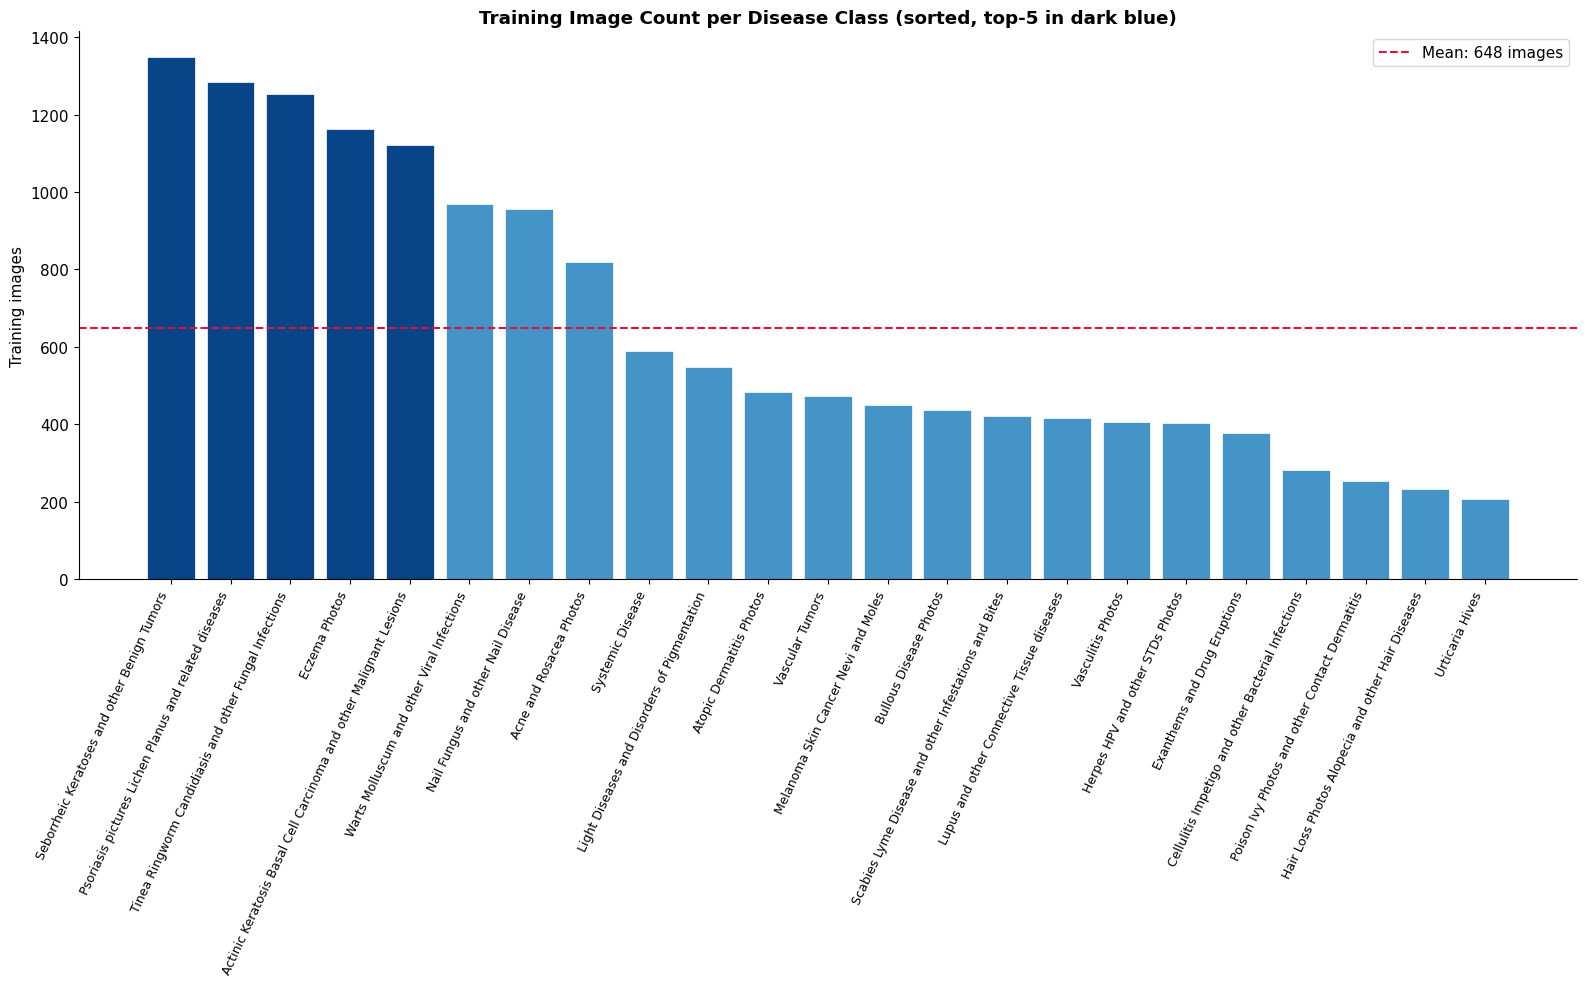

In [7]:
fig, ax = plt.subplots(figsize=(16, 10))
colors = [BLUE_PAL[0] if i < 5 else BLUE_PAL[4] for i in range(len(dist_df))]
ax.bar(dist_df['Class'], dist_df['Train'], color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(dist_df['Train'].mean(), color='crimson', linestyle='--', linewidth=1.5,
           label=f"Mean: {dist_df['Train'].mean():.0f} images")
ax.set_xticks(range(len(dist_df)))
ax.set_xticklabels(dist_df['Class'], rotation=65, ha='right', fontsize=9)
ax.set_ylabel('Training images')
ax.set_title('Training Image Count per Disease Class (sorted, top-5 in dark blue)')
ax.legend()
plt.tight_layout()
plt.show()

## 2.2 Sorted Horizontal bar chart of training class counts

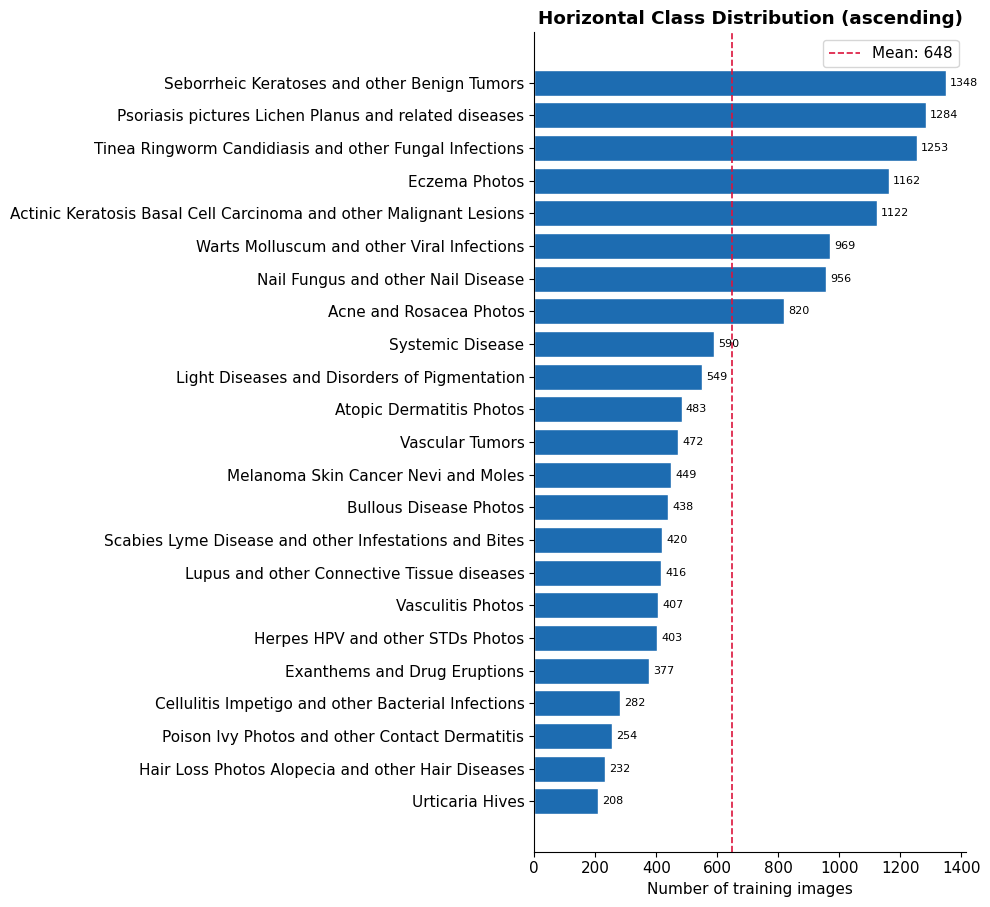

In [8]:
fig, ax = plt.subplots(figsize=(10, max(6, len(dist_df)*0.4)))
sorted_asc = dist_df.sort_values('Train')
bars = ax.barh(sorted_asc['Class'], sorted_asc['Train'],
               color=BLUE_PAL[2], edgecolor='white')
ax.bar_label(bars, fmt='%d', padding=3, fontsize=8)
ax.axvline(dist_df['Train'].mean(), color='crimson', linestyle='--', linewidth=1.2,
           label=f"Mean: {dist_df['Train'].mean():.0f}")
ax.set_xlabel('Number of training images')
ax.set_title('Horizontal Class Distribution (ascending)')
ax.legend()
plt.tight_layout()
plt.show()

## 2.3 Pie chart - share of total training data per class

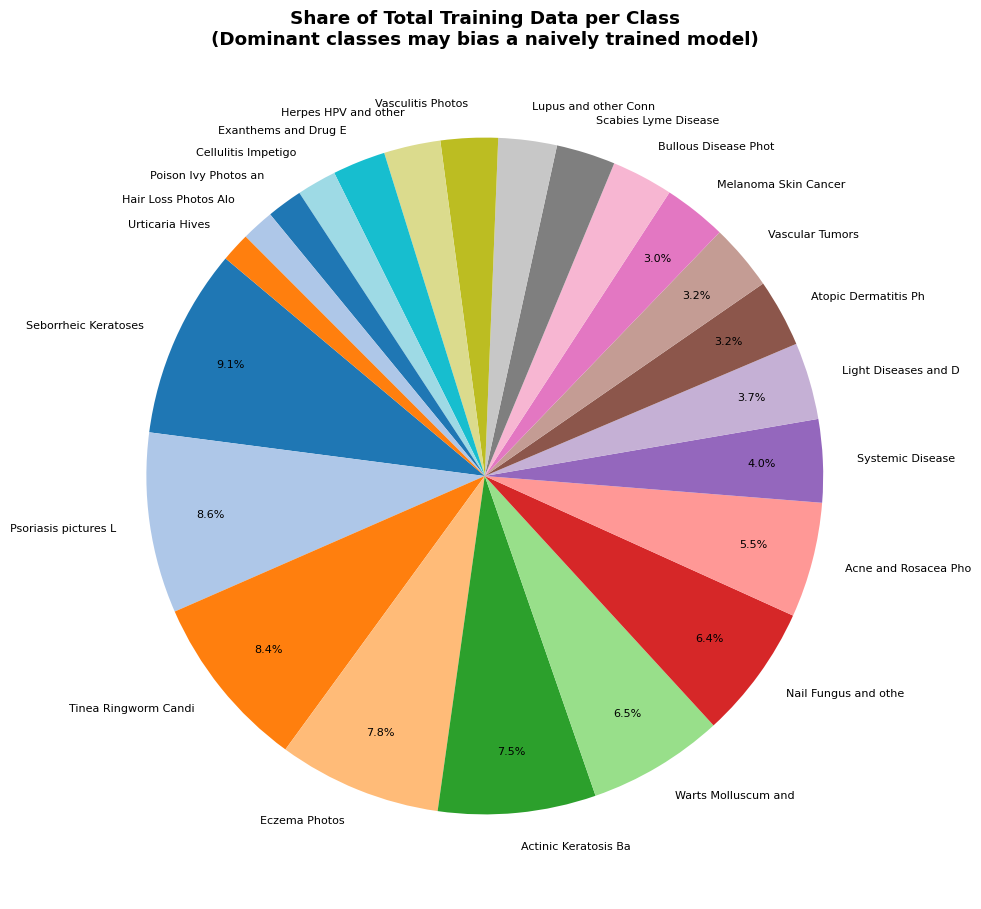

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))
wedge_colors = sns.color_palette('tab20', len(dist_df))
wedges, texts, autotexts = ax.pie(
    dist_df['Train'],
    labels=[c[:20] for c in dist_df['Class']],
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
    colors=wedge_colors,
    startangle=140,
    pctdistance=0.82,
    textprops={'fontsize': 8}
)
ax.set_title('Share of Total Training Data per Class\n'
             '(Dominant classes may bias a naively trained model)')
plt.tight_layout()
plt.show()

## 2.4 Cumulative distribution - how many classes cover 80% of data?

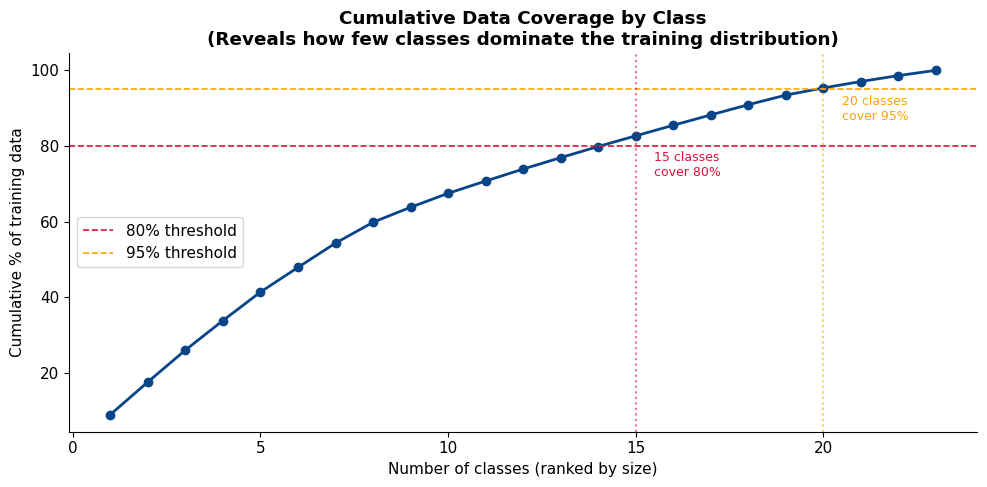

In [10]:
sorted_pct = dist_df.sort_values('Train_Pct', ascending=False)
cumsum = sorted_pct['Train_Pct'].cumsum().values

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumsum)+1), cumsum, marker='o', color=BLUE_PAL[0], linewidth=2)
ax.axhline(80, color='crimson', linestyle='--', linewidth=1.2, label='80% threshold')
ax.axhline(95, color='orange',  linestyle='--', linewidth=1.2, label='95% threshold')
idx_80 = next(i for i,v in enumerate(cumsum) if v >= 80) + 1
idx_95 = next(i for i,v in enumerate(cumsum) if v >= 95) + 1
ax.axvline(idx_80, color='crimson', linestyle=':', alpha=0.6)
ax.axvline(idx_95, color='orange',  linestyle=':', alpha=0.6)
ax.annotate(f'{idx_80} classes\ncover 80%', xy=(idx_80, 80),
            xytext=(idx_80+0.5, 72), fontsize=9, color='crimson')
ax.annotate(f'{idx_95} classes\ncover 95%', xy=(idx_95, 95),
            xytext=(idx_95+0.5, 87), fontsize=9, color='orange')
ax.set_xlabel('Number of classes (ranked by size)')
ax.set_ylabel('Cumulative % of training data')
ax.set_title('Cumulative Data Coverage by Class\n'
             '(Reveals how few classes dominate the training distribution)')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
largest  = dist_df['Train'].max()
smallest = dist_df['Train'].min()
ratio    = largest / smallest

sorted_counts = sorted(dist_df['Train'])
n = len(sorted_counts)
gini = (2*sum((i+1)*v for i,v in enumerate(sorted_counts)) /
        (n * dist_df['Train'].sum())) - (n+1)/n

print('CLASS IMBALANCE DIAGNOSTICS')
print('='*55)
print(f"  Largest  : {dist_df.loc[dist_df['Train'].idxmax(),'Class']} ({largest:,})")
print(f"  Smallest : {dist_df.loc[dist_df['Train'].idxmin(),'Class']} ({smallest:,})")
print(f'  Ratio    : {ratio:.1f}:1')
print(f'  Gini     : {gini:.3f}  (0=perfect balance, 1=max imbalance)')
print(f"  Mean/Med : {dist_df['Train'].mean():.0f} / {dist_df['Train'].median():.0f}")

if   ratio > 10: sev = 'SEVERE   — weighted loss + oversampling required'
elif ratio >  4: sev = 'MODERATE — weighted loss function recommended'
elif ratio >  2: sev = 'MILD     — monitor per-class metrics'
else:            sev = 'BALANCED — standard training OK'
print(f'\n  Severity : {sev}')

CLASS IMBALANCE DIAGNOSTICS
  Largest  : Seborrheic Keratoses and other Benign Tumors (1,348)
  Smallest : Urticaria Hives (208)
  Ratio    : 6.5:1
  Gini     : 0.308  (0=perfect balance, 1=max imbalance)
  Mean/Med : 648 / 472

  Severity : MODERATE — weighted loss function recommended


## 2.5 Box-plot of class size distribution

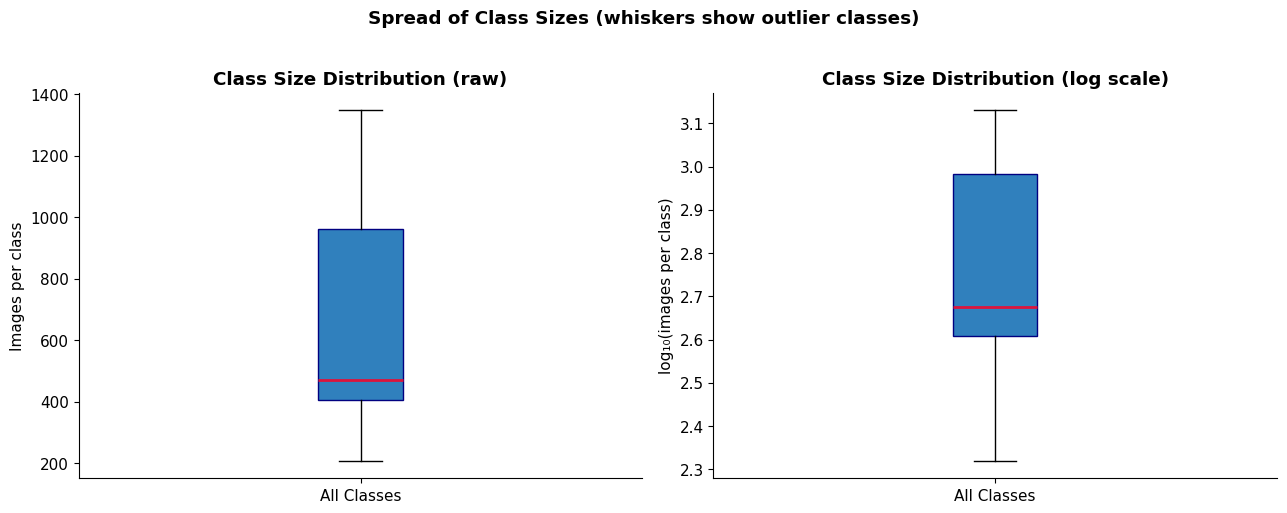

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
axes[0].boxplot(dist_df['Train'], vert=True, patch_artist=True,
                boxprops=dict(facecolor=BLUE_PAL[3], color='navy'),
                medianprops=dict(color='crimson', linewidth=2))
axes[0].set_xticks([1]); axes[0].set_xticklabels(['All Classes'])
axes[0].set_ylabel('Images per class')
axes[0].set_title('Class Size Distribution (raw)')

# Log scale for clearer spread
axes[1].boxplot(np.log10(dist_df['Train']+1), vert=True, patch_artist=True,
                boxprops=dict(facecolor=BLUE_PAL[3], color='navy'),
                medianprops=dict(color='crimson', linewidth=2))
axes[1].set_xticks([1]); axes[1].set_xticklabels(['All Classes'])
axes[1].set_ylabel('log₁₀(images per class)')
axes[1].set_title('Class Size Distribution (log scale)')

plt.suptitle('Spread of Class Sizes (whiskers show outlier classes)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 3 · Train / Test Split Integrity
*Verify the split is proportional and no class is severely under-represented in the test set.*

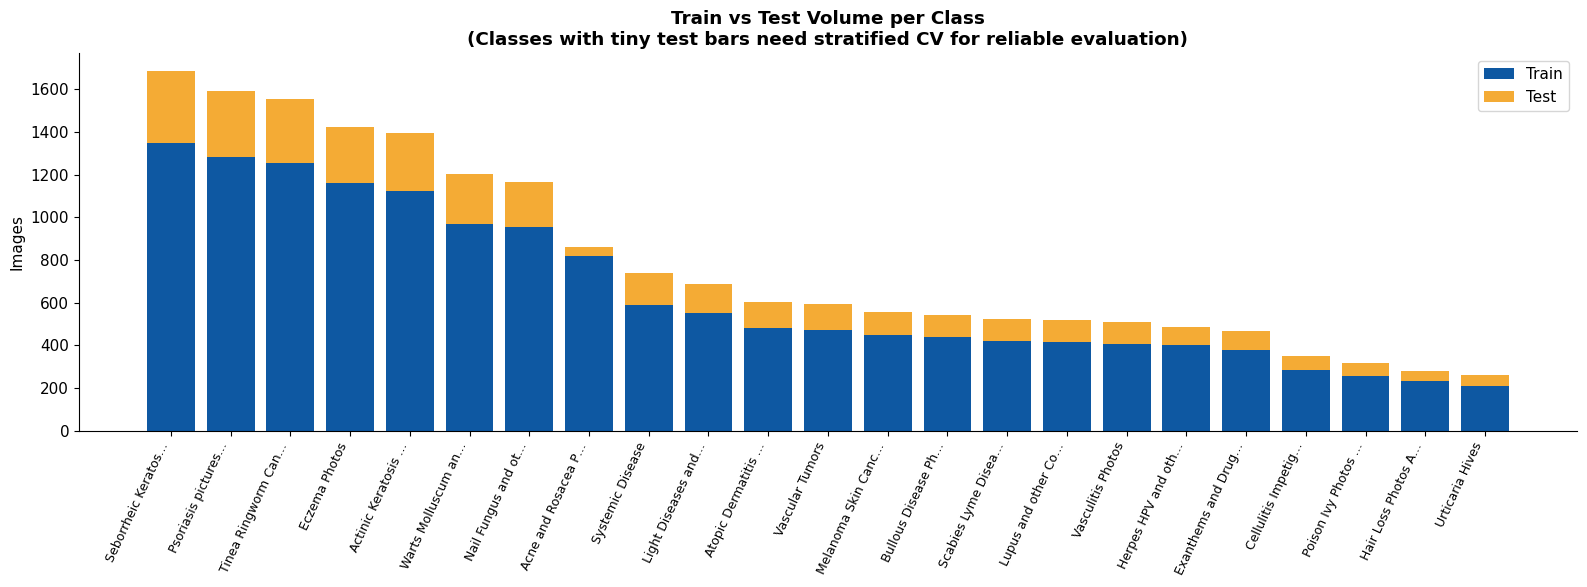

In [13]:
sorted_dist = dist_df.sort_values('Total', ascending=False).reset_index(drop=True)
short = [c[:18]+'…' if len(c)>18 else c for c in sorted_dist['Class']]
x = np.arange(len(sorted_dist))

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x, sorted_dist['Train'], label='Train', color=BLUE_PAL[1])
ax.bar(x, sorted_dist['Test'],  bottom=sorted_dist['Train'], label='Test', color='#f39c12', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(short, rotation=65, ha='right', fontsize=9)
ax.set_ylabel('Images'); ax.legend()
ax.set_title('Train vs Test Volume per Class\n'
             '(Classes with tiny test bars need stratified CV for reliable evaluation)')
plt.tight_layout()
plt.show()

## 3.1 Train/Test split ratio per class (scatter)

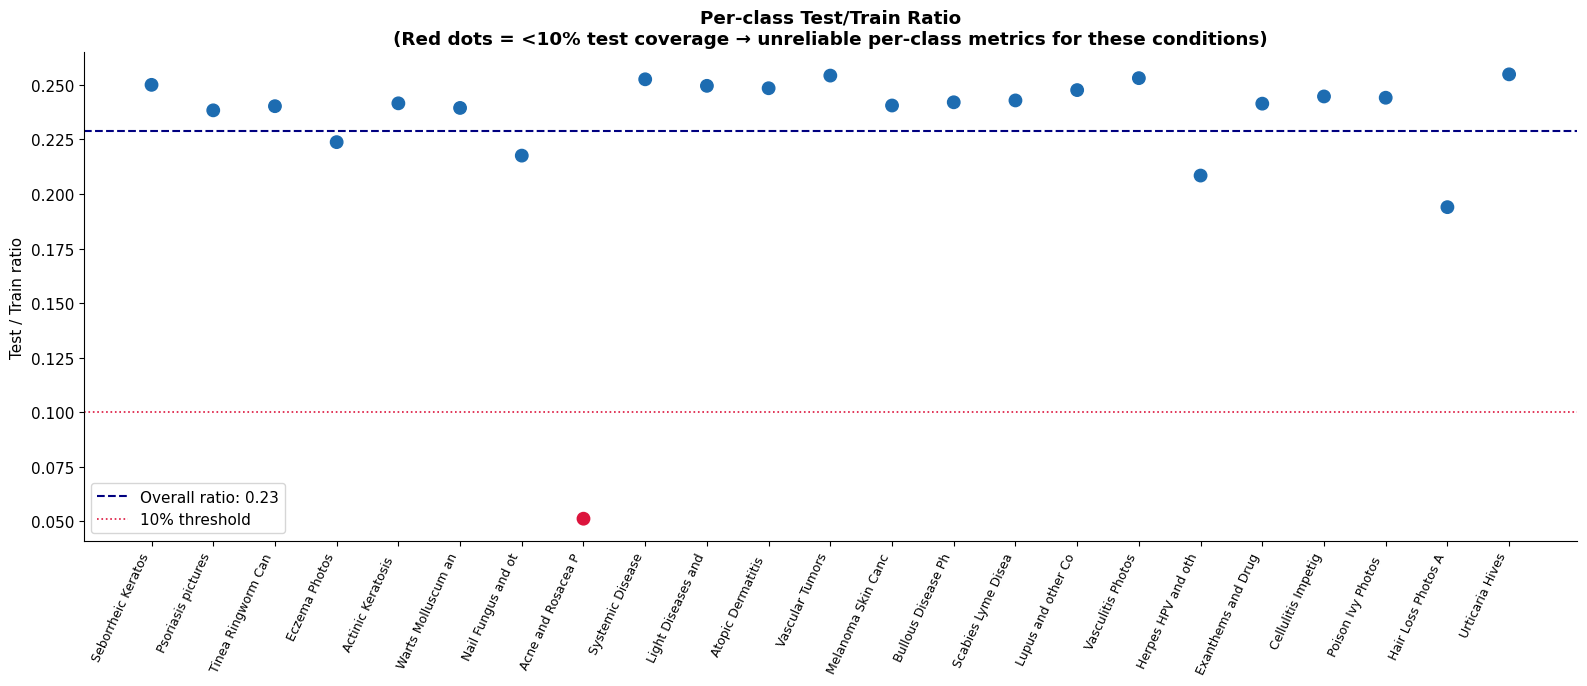

In [14]:
dist_df['TestTrainRatio'] = dist_df['Test'] / dist_df['Train']
overall_ratio = dist_df['Test'].sum() / dist_df['Train'].sum()

fig, ax = plt.subplots(figsize=(16, 7))
colors_scatter = ['crimson' if r < 0.10 else BLUE_PAL[2] for r in dist_df['TestTrainRatio']]
ax.scatter(range(len(dist_df)), dist_df['TestTrainRatio'], c=colors_scatter, s=80, zorder=3)
ax.axhline(overall_ratio, color='navy', linestyle='--', linewidth=1.5,
           label=f'Overall ratio: {overall_ratio:.2f}')
ax.axhline(0.10, color='crimson', linestyle=':', linewidth=1.2, label='10% threshold')
ax.set_xticks(range(len(dist_df)))
ax.set_xticklabels([c[:18] for c in dist_df['Class']], rotation=65, ha='right', fontsize=9)
ax.set_ylabel('Test / Train ratio')
ax.set_title('Per-class Test/Train Ratio\n'
             '(Red dots = <10% test coverage → unreliable per-class metrics for these conditions)')
ax.legend()
plt.tight_layout()
plt.show()

## 3.2 Heatmap - log-scale counts for both splits

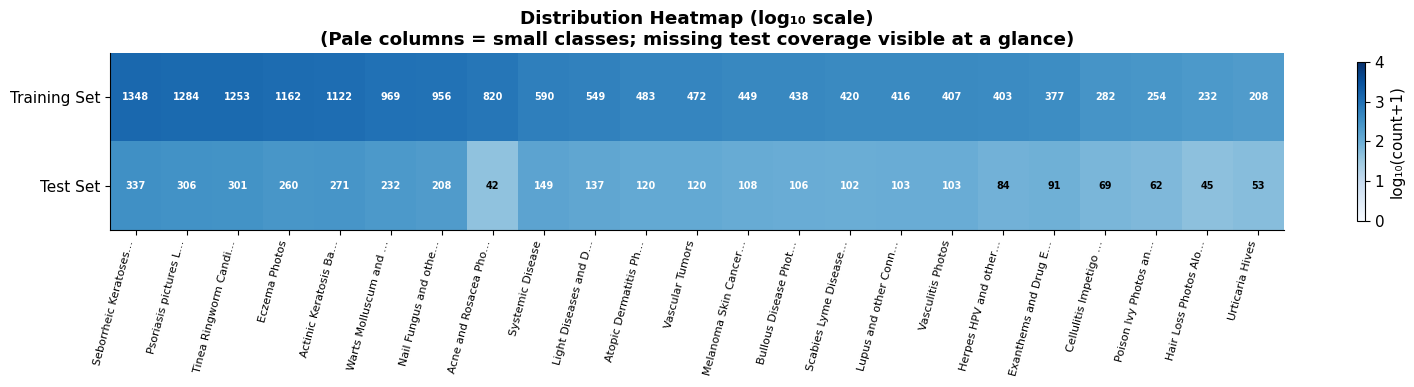

In [15]:
log_data = pd.DataFrame({
    'Training Set': np.log10(sorted_dist['Train'] + 1),
    'Test Set':     np.log10(sorted_dist['Test']  + 1),
}).T
short_labels = [c[:20]+'…' if len(c)>20 else c for c in sorted_dist['Class']]

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(log_data, cmap='Blues', aspect='auto', vmin=0, vmax=4)
ax.set_yticks([0,1]); ax.set_yticklabels(['Training Set','Test Set'])
ax.set_xticks(range(len(sorted_dist)))
ax.set_xticklabels(short_labels, rotation=75, ha='right', fontsize=8)
ax.set_title('Distribution Heatmap (log₁₀ scale)\n'
             '(Pale columns = small classes; missing test coverage visible at a glance)')
for r in range(2):
    for c in range(len(sorted_dist)):
        val = sorted_dist.iloc[c]['Train'] if r==0 else sorted_dist.iloc[c]['Test']
        if val > 0:
            col = 'white' if np.log10(val+1)>2 else 'black'
            ax.text(c, r, str(val), ha='center', va='center', fontsize=7, color=col, fontweight='bold')
plt.colorbar(im, ax=ax, label='log₁₀(count+1)', shrink=0.9)
plt.tight_layout()
plt.show()

---
## 4 · Image Properties
*Determines resize strategy, normalisation approach, and data loader configuration.*

In [16]:
sizes, modes, aspects, corrupted = [], [], [], []

for cls in classes:
    folder = os.path.join(train_path, cls)
    for fname in os.listdir(folder):
        if not fname.lower().endswith(('.png','.jpg','.jpeg','.bmp','.tiff')): continue
        fpath = os.path.join(folder, fname)
        try:
            with Image.open(fpath) as img: img.verify()
            with Image.open(fpath) as img:
                w, h = img.size
                sizes.append((w, h))
                modes.append(img.mode)
                aspects.append(w / h)
        except Exception:
            corrupted.append(fpath)

widths  = [s[0] for s in sizes]
heights = [s[1] for s in sizes]
mode_counts = Counter(modes)
grayscale_pct = sum(n for m,n in mode_counts.items() if m in ('L','1','P')) / len(modes) * 100

print(f'Images analysed : {len(sizes):,}  |  Corrupted: {len(corrupted)}')
print(f'Width  — min:{min(widths)}, max:{max(widths)}, mean:{np.mean(widths):.0f}, std:{np.std(widths):.0f}')
print(f'Height — min:{min(heights)}, max:{max(heights)}, mean:{np.mean(heights):.0f}, std:{np.std(heights):.0f}')
print(f'Aspect ratio — min:{min(aspects):.2f}, max:{max(aspects):.2f}, mean:{np.mean(aspects):.2f}')
print(f'\nColor modes:')
for m, n in mode_counts.most_common():
    print(f'  {m}: {n:,} ({n/len(modes)*100:.1f}%)')

Images analysed : 14,894  |  Corrupted: 0
Width  — min:314, max:720, mean:657, std:105
Height — min:359, max:1128, mean:546, std:109
Aspect ratio — min:0.44, max:1.84, mean:1.28

Color modes:
  RGB: 14,894 (100.0%)


## 4.1 Width & Height histograms

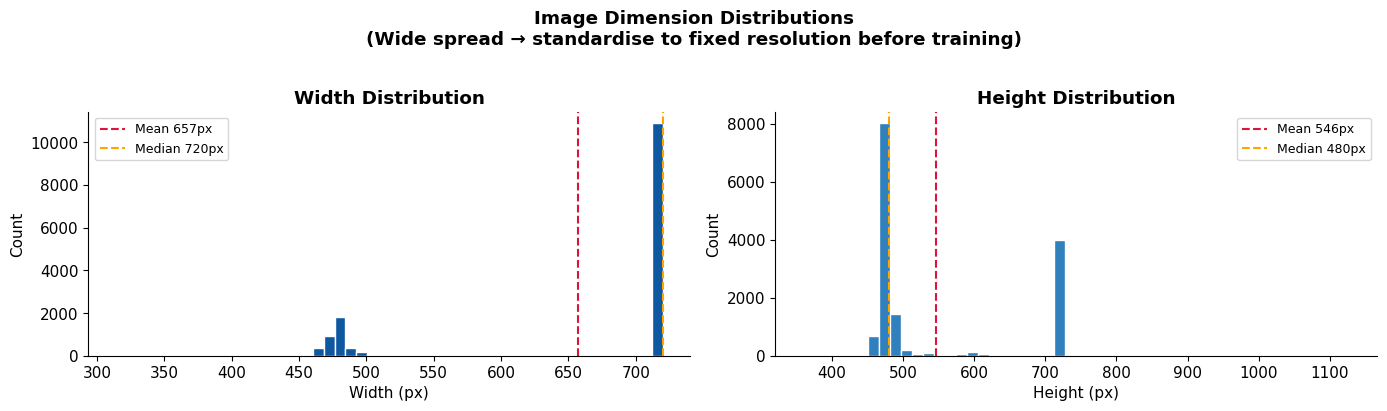

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(widths,  bins=50, color=BLUE_PAL[1], edgecolor='white')
axes[0].axvline(np.mean(widths),  color='crimson', linestyle='--', label=f'Mean {np.mean(widths):.0f}px')
axes[0].axvline(np.median(widths),color='orange',  linestyle='--', label=f'Median {np.median(widths):.0f}px')
axes[0].set_xlabel('Width (px)'); axes[0].set_ylabel('Count')
axes[0].set_title('Width Distribution'); axes[0].legend(fontsize=9)

axes[1].hist(heights, bins=50, color=BLUE_PAL[3], edgecolor='white')
axes[1].axvline(np.mean(heights),  color='crimson', linestyle='--', label=f'Mean {np.mean(heights):.0f}px')
axes[1].axvline(np.median(heights),color='orange',  linestyle='--', label=f'Median {np.median(heights):.0f}px')
axes[1].set_xlabel('Height (px)'); axes[1].set_ylabel('Count')
axes[1].set_title('Height Distribution'); axes[1].legend(fontsize=9)

fig.suptitle('Image Dimension Distributions\n'
             '(Wide spread → standardise to fixed resolution before training)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4.2 Width vs Height scatter - cluster map

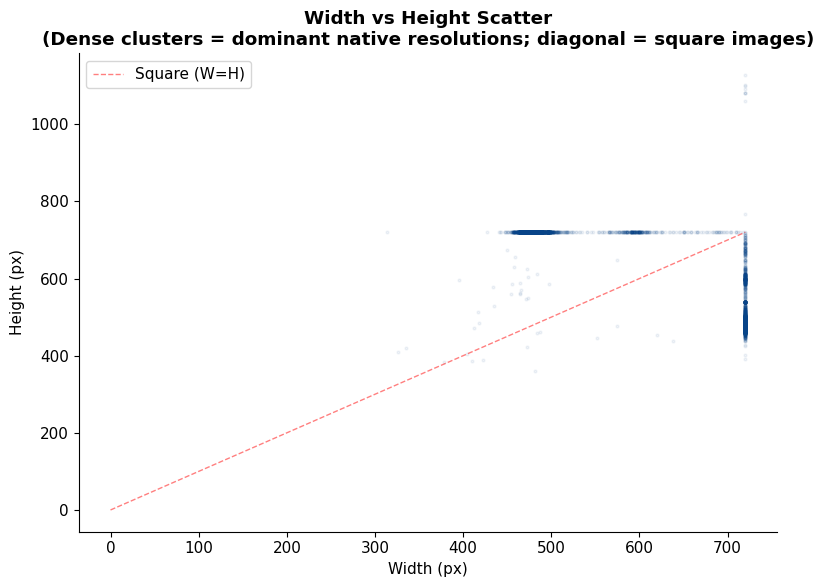

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(widths, heights, alpha=0.06, s=4, color=BLUE_PAL[0])
ax.plot([0, max(widths)], [0, max(widths)], 'r--', linewidth=1, alpha=0.5, label='Square (W=H)')
ax.set_xlabel('Width (px)'); ax.set_ylabel('Height (px)')
ax.set_title('Width vs Height Scatter\n'
             '(Dense clusters = dominant native resolutions; diagonal = square images)')
ax.legend()
plt.tight_layout()
plt.show()

## 4.3 Aspect ratio distribution + clinical annotation

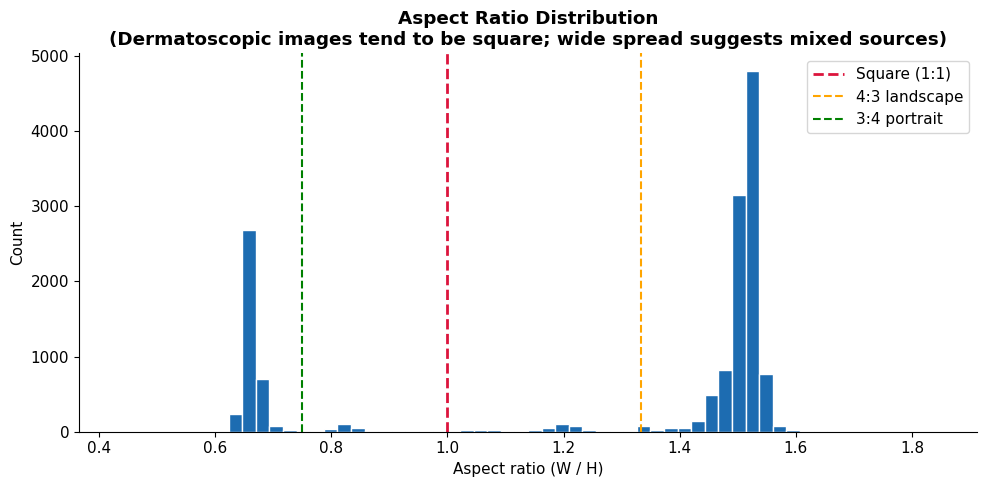

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(aspects, bins=60, color=BLUE_PAL[2], edgecolor='white')
ax.axvline(1.0, color='crimson', linestyle='--', linewidth=2, label='Square (1:1)')
ax.axvline(4/3, color='orange',  linestyle='--', linewidth=1.5, label='4:3 landscape')
ax.axvline(3/4, color='green',   linestyle='--', linewidth=1.5, label='3:4 portrait')
ax.set_xlabel('Aspect ratio (W / H)'); ax.set_ylabel('Count')
ax.set_title('Aspect Ratio Distribution\n'
             '(Dermatoscopic images tend to be square; wide spread suggests mixed sources)')
ax.legend()
plt.tight_layout()
plt.show()

## 4.4 Color mode distribution (bar)

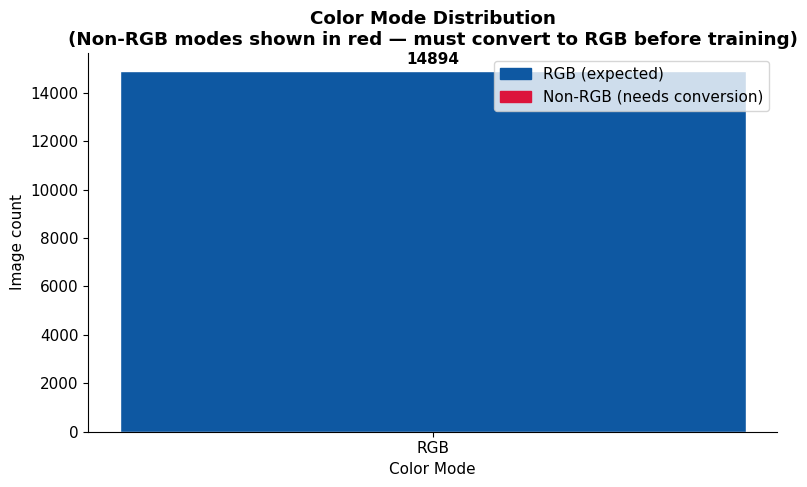

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
mode_labels = list(mode_counts.keys())
mode_vals   = list(mode_counts.values())
bar_colors  = ['crimson' if m != 'RGB' else BLUE_PAL[1] for m in mode_labels]
bars = ax.bar(mode_labels, mode_vals, color=bar_colors, edgecolor='white')
ax.bar_label(bars, fmt='%d', padding=3, fontweight='bold')
ax.set_xlabel('Color Mode'); ax.set_ylabel('Image count')
ax.set_title('Color Mode Distribution\n'
             '(Non-RGB modes shown in red — must convert to RGB before training)')
rgb_patch   = mpatches.Patch(color=BLUE_PAL[1], label='RGB (expected)')
other_patch = mpatches.Patch(color='crimson',   label='Non-RGB (needs conversion)')
ax.legend(handles=[rgb_patch, other_patch])
plt.tight_layout()
plt.show()

---
# 5 · Colour Analysis
*Skin condition diagnosis is fundamentally a colour-sensitive task. Erythema, pigmentation, pallor, and cyanosis are all colour phenomena. This section quantifies how much colour varies within and between classes.*

In [21]:
SAMPLE_PER_CLASS = 30
quality_rows = []

for cls in classes:
    folder   = os.path.join(train_path, cls)
    all_imgs = [f for f in os.listdir(folder)
                if f.lower().endswith(('.png','.jpg','.jpeg','.bmp','.tiff'))]
    sample   = random.sample(all_imgs, min(SAMPLE_PER_CLASS, len(all_imgs)))

    for fname in sample:
        fpath = os.path.join(folder, fname)
        try:
            with Image.open(fpath) as img:
                rgb      = img.convert('RGB')
                arr      = np.array(rgb).astype(float)
                r_m, g_m, b_m = arr[:,:,0].mean(), arr[:,:,1].mean(), arr[:,:,2].mean()
                gray_arr = np.array(rgb.convert('L'))
                quality_rows.append({
                    'Class':       cls,
                    'Brightness':  gray_arr.mean(),
                    'Contrast':    gray_arr.std(),
                    'R_mean':      r_m,
                    'G_mean':      g_m,
                    'B_mean':      b_m,
                    # Redness index: R/(G+B) — clinically meaningful for erythema/inflammation
                    'Redness_idx': r_m / (g_m + b_m + 1e-6),
                    # Colour saturation proxy: std across channels
                    'Saturation':  np.std([r_m, g_m, b_m]),
                    # Dark pixel ratio: fraction with luminance < 50
                    'Dark_ratio':  (gray_arr < 50).mean(),
                })
        except Exception:
            continue

qual_df = pd.DataFrame(quality_rows)
print(f'Quality stats: {len(qual_df)} images across {qual_df["Class"].nunique()} classes.')

Quality stats: 690 images across 23 classes.


## 5.1 Global brightness & contrast overview

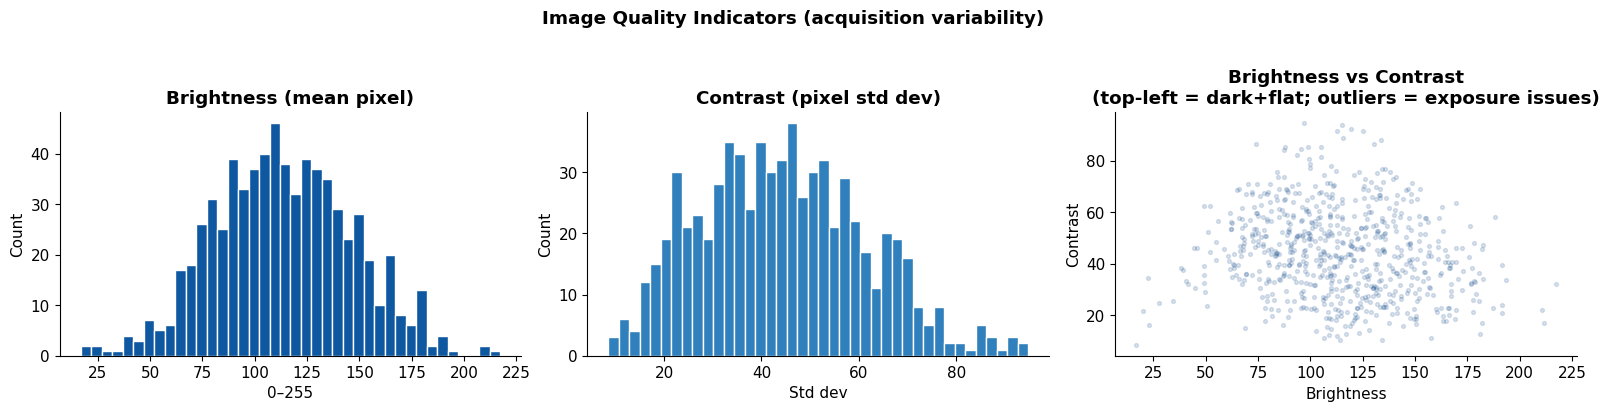

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(qual_df['Brightness'], bins=40, color=BLUE_PAL[1], edgecolor='white')
axes[0].set_title('Brightness (mean pixel)'); axes[0].set_xlabel('0–255')

axes[1].hist(qual_df['Contrast'], bins=40, color=BLUE_PAL[3], edgecolor='white')
axes[1].set_title('Contrast (pixel std dev)'); axes[1].set_xlabel('Std dev')

axes[2].scatter(qual_df['Brightness'], qual_df['Contrast'],
                alpha=0.15, s=8, color=BLUE_PAL[0])
axes[2].set_title('Brightness vs Contrast\n(top-left = dark+flat; outliers = exposure issues)')
axes[2].set_xlabel('Brightness'); axes[2].set_ylabel('Contrast')

for ax in axes: ax.set_ylabel('Count') if ax != axes[2] else None
fig.suptitle('Image Quality Indicators (acquisition variability)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5.2 Per-class brightness boxplot

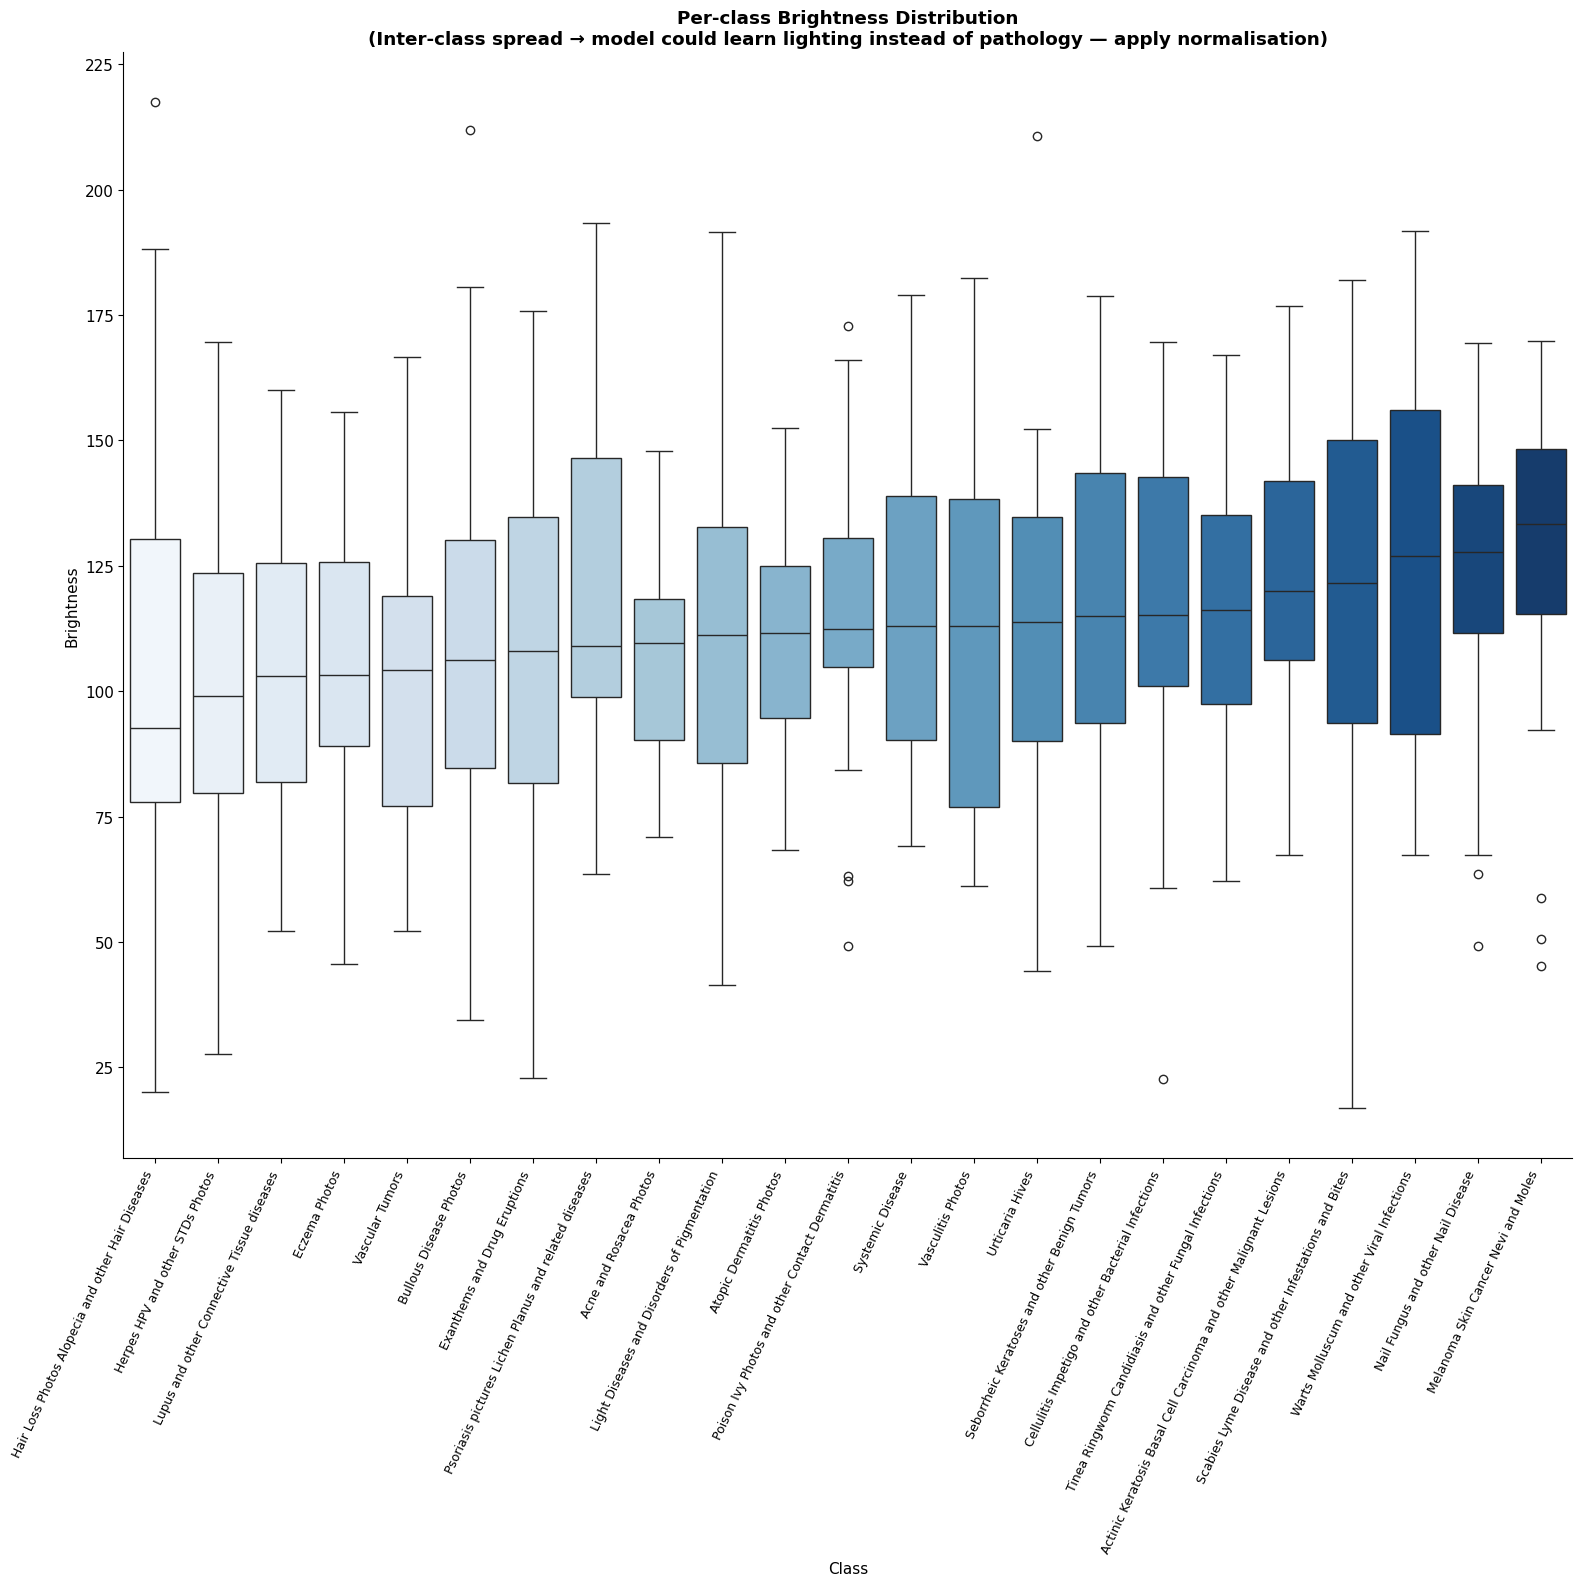

In [23]:
order_b = qual_df.groupby('Class')['Brightness'].median().sort_values().index
fig, ax = plt.subplots(figsize=(16, 16))
sns.boxplot(data=qual_df, x='Class', y='Brightness', order=order_b, palette='Blues', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=65, ha='right', fontsize=9)
ax.set_title('Per-class Brightness Distribution\n'
             '(Inter-class spread → model could learn lighting instead of pathology — apply normalisation)')
plt.tight_layout()
plt.show()

## 5.3 Per-class Redness Index (clinical marker)

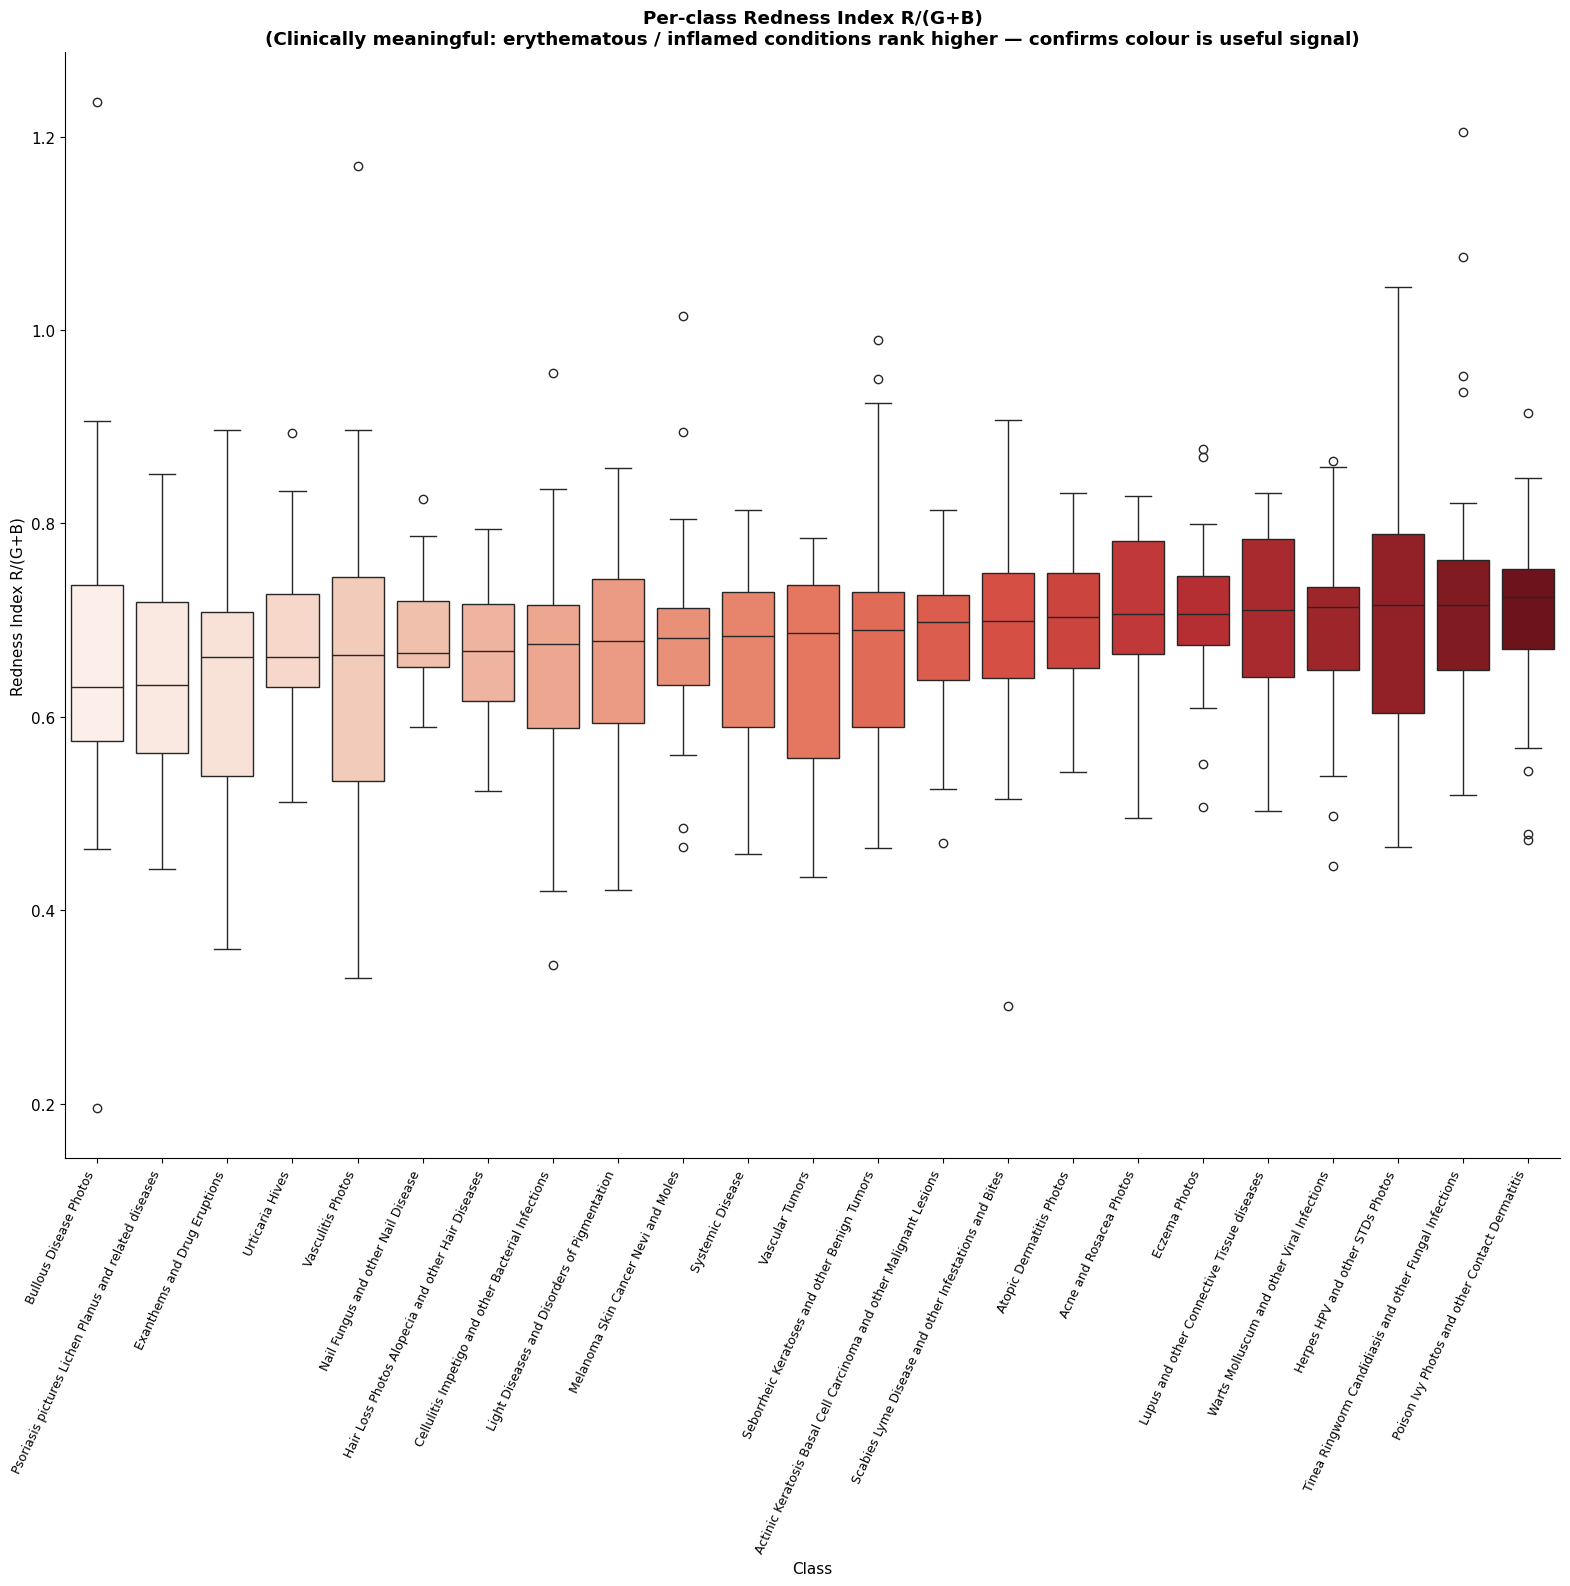

In [24]:
order_r = qual_df.groupby('Class')['Redness_idx'].median().sort_values().index
fig, ax = plt.subplots(figsize=(16, 16))
sns.boxplot(data=qual_df, x='Class', y='Redness_idx', order=order_r, palette='Reds', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=65, ha='right', fontsize=9)
ax.set_ylabel('Redness Index R/(G+B)')
ax.set_title('Per-class Redness Index R/(G+B)\n'
             '(Clinically meaningful: erythematous / inflamed conditions rank higher — confirms colour is useful signal)')
plt.tight_layout()
plt.show()

## 5.4 Mean RGB channel values per class

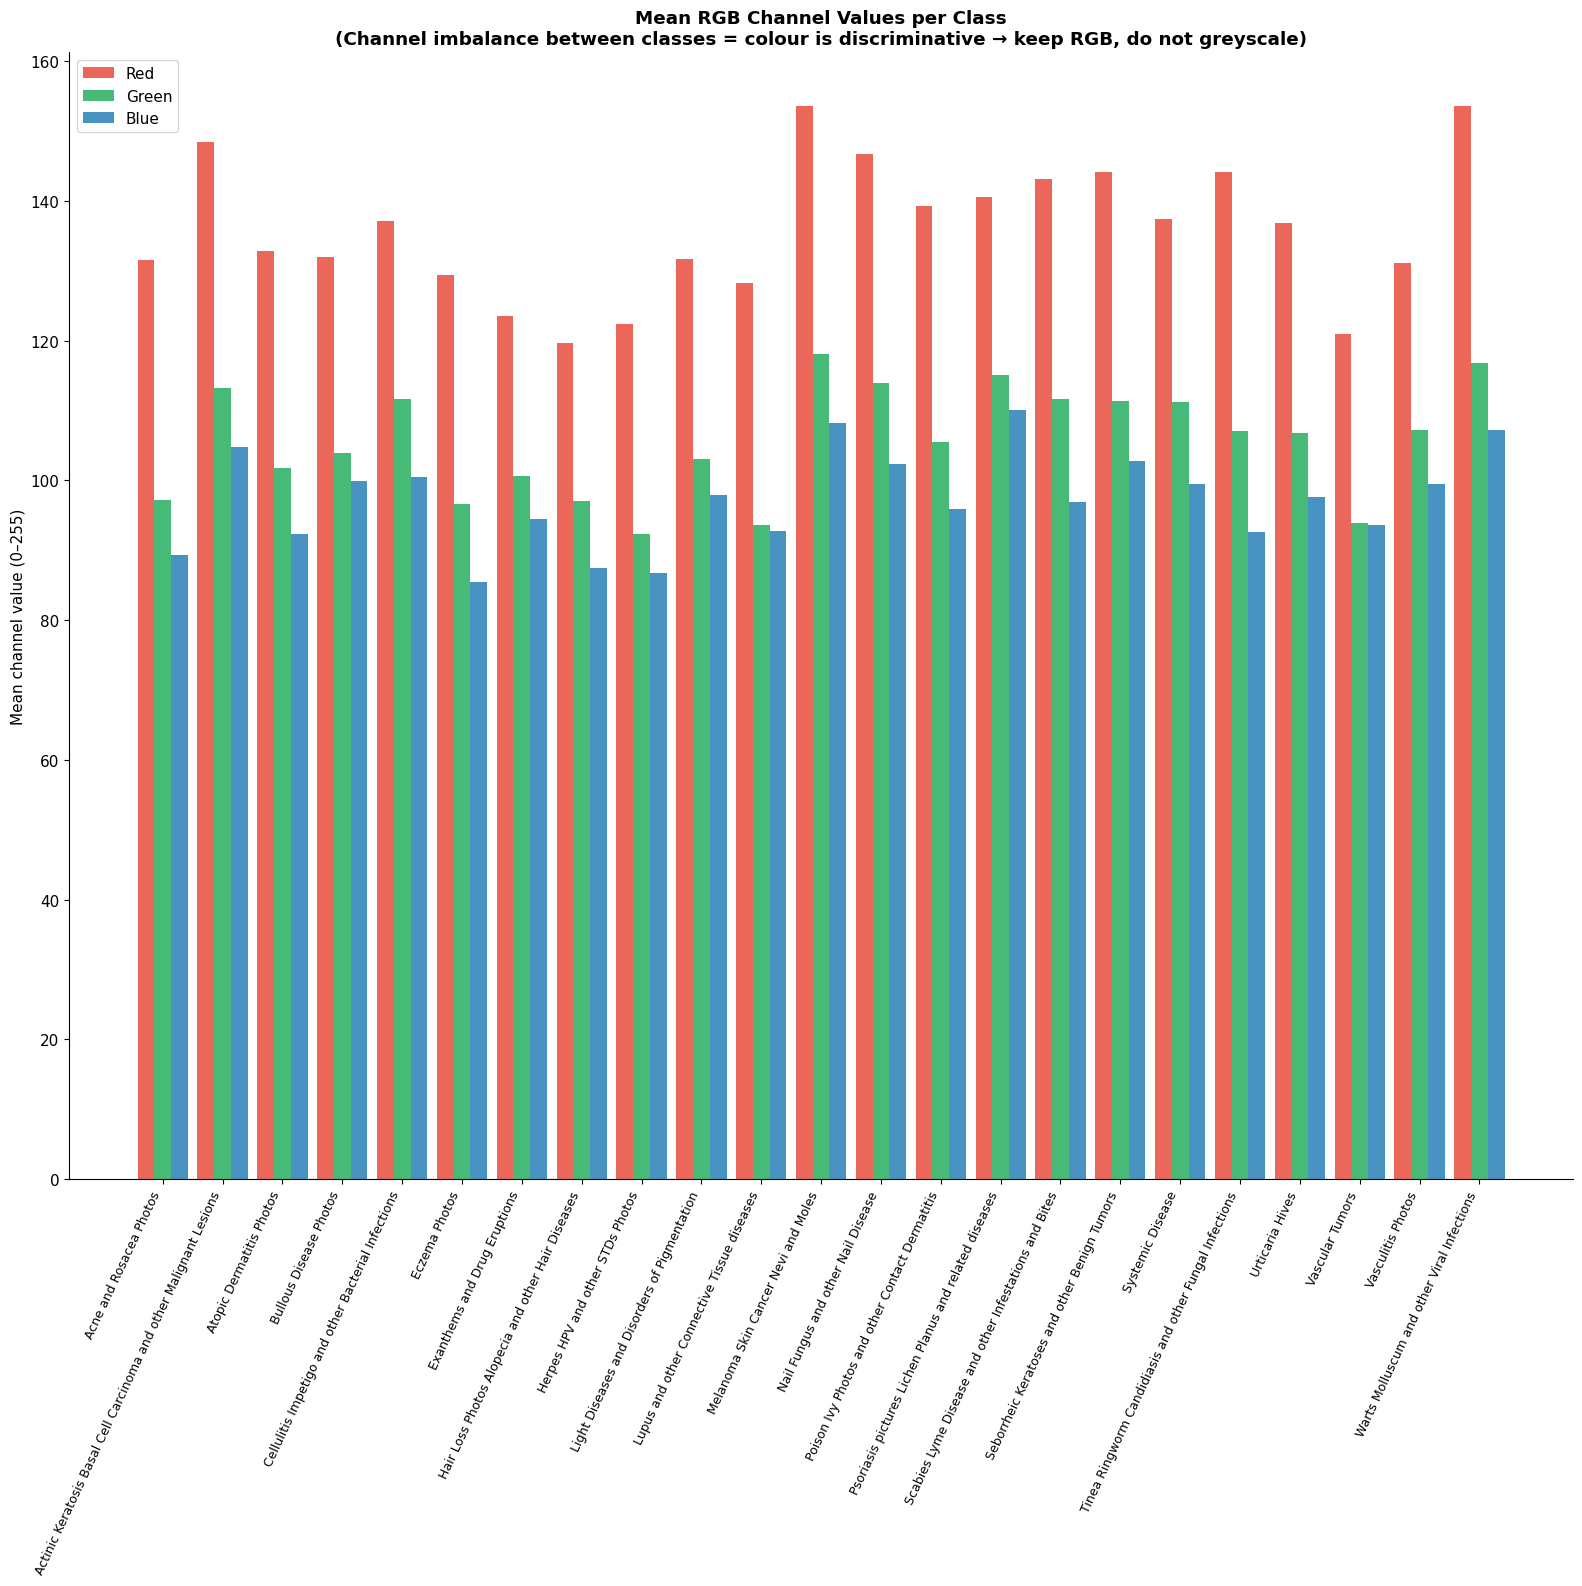

In [25]:
ch = qual_df.groupby('Class')[['R_mean','G_mean','B_mean']].mean()
x = np.arange(len(ch)); w = 0.28

fig, ax = plt.subplots(figsize=(16, 16))
ax.bar(x-w, ch['R_mean'], w, label='Red',   color='#e74c3c', alpha=0.85)
ax.bar(x,   ch['G_mean'], w, label='Green', color='#27ae60', alpha=0.85)
ax.bar(x+w, ch['B_mean'], w, label='Blue',  color='#2980b9', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(ch.index, rotation=65, ha='right', fontsize=9)
ax.set_ylabel('Mean channel value (0–255)')
ax.set_title('Mean RGB Channel Values per Class\n'
             '(Channel imbalance between classes = colour is discriminative → keep RGB, do not greyscale)')
ax.legend()
plt.tight_layout()
plt.show()

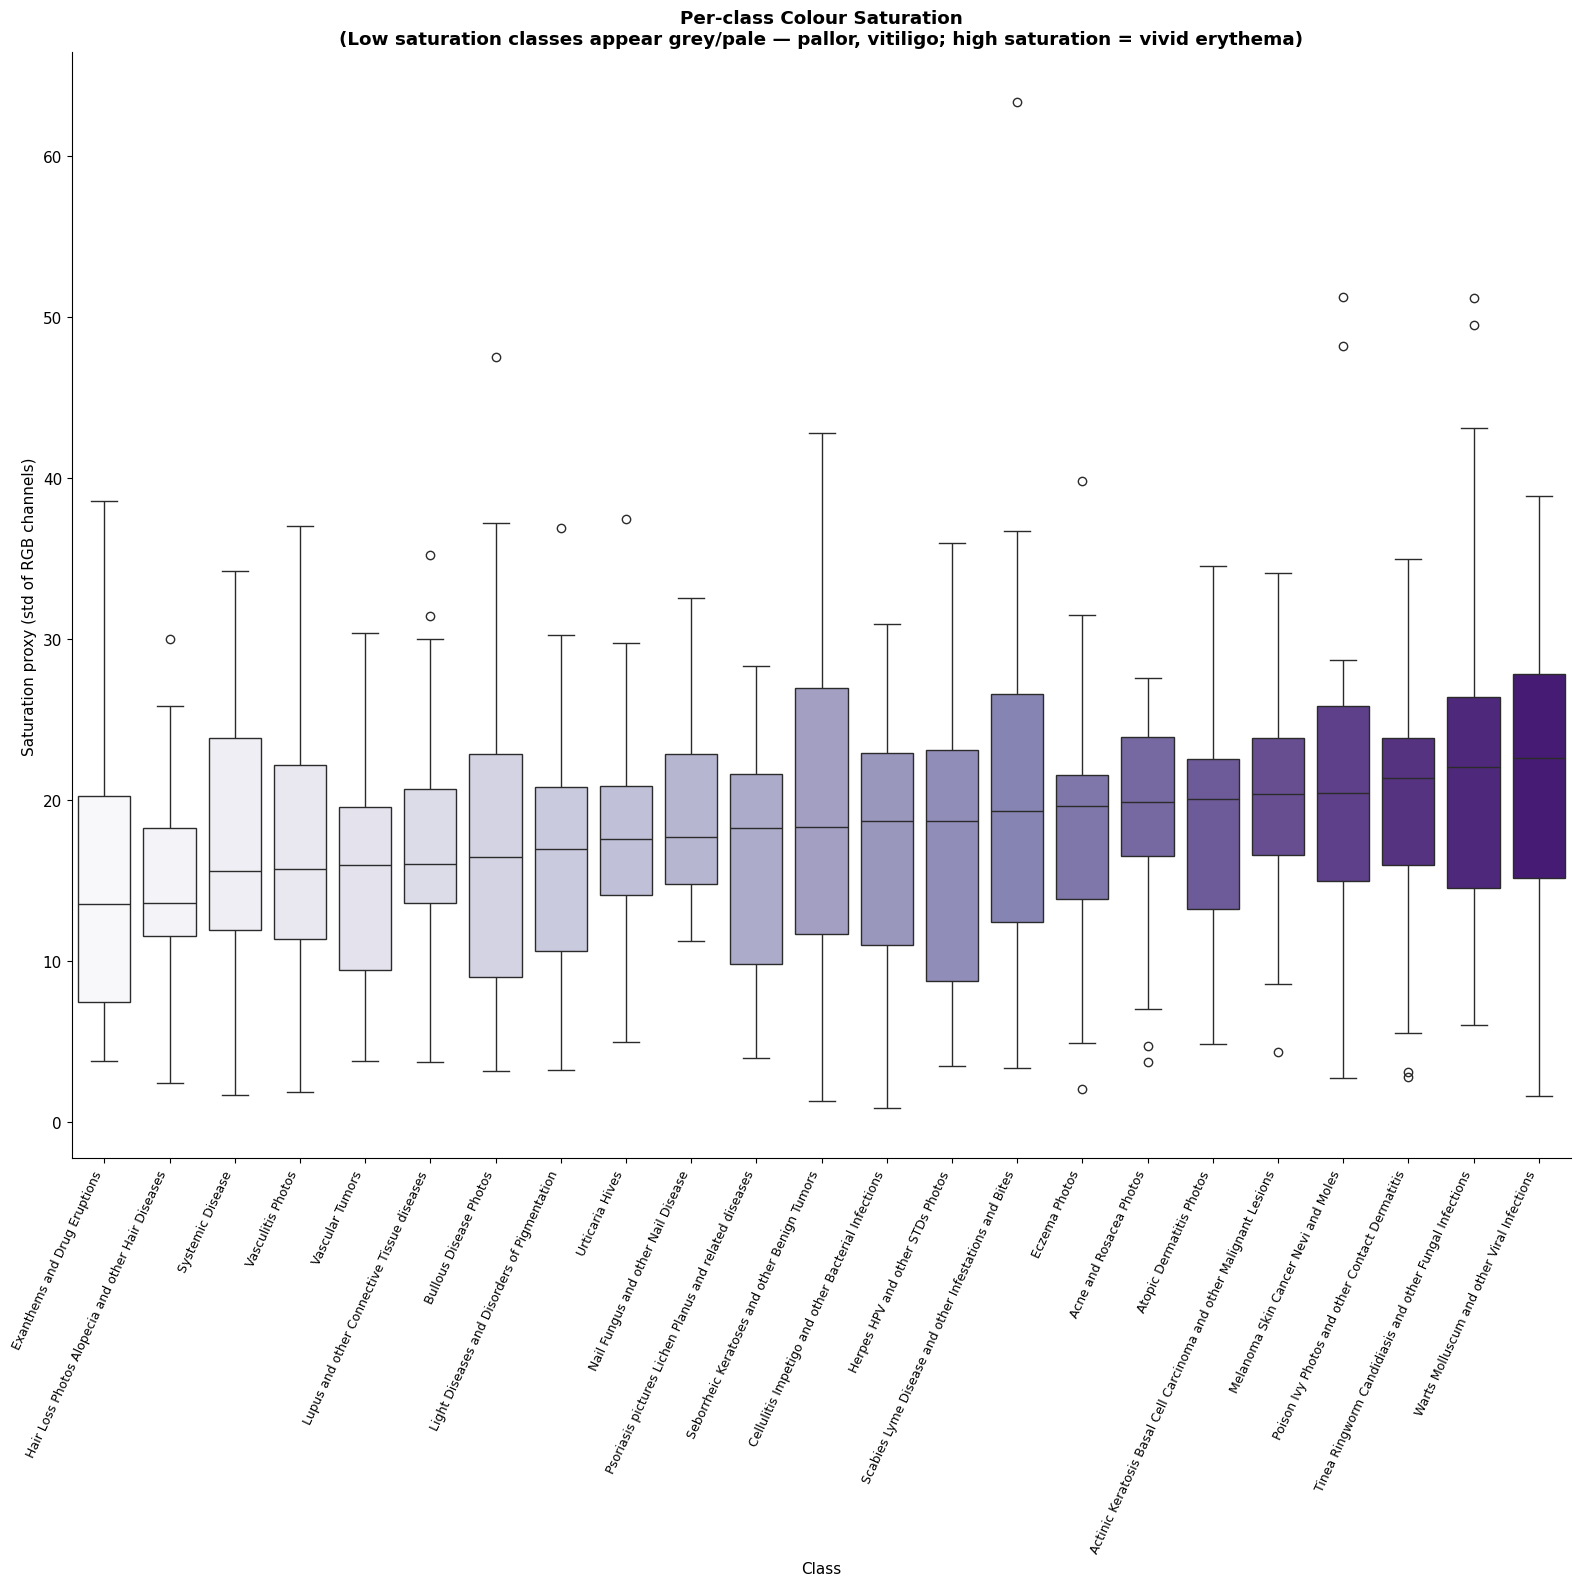

In [26]:
order_s = qual_df.groupby('Class')['Saturation'].median().sort_values().index
fig, ax = plt.subplots(figsize=(16, 16))
sns.boxplot(data=qual_df, x='Class', y='Saturation', order=order_s,
            palette='Purples', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=65, ha='right', fontsize=9)
ax.set_ylabel('Saturation proxy (std of RGB channels)')
ax.set_title('Per-class Colour Saturation\n'
             '(Low saturation classes appear grey/pale — pallor, vitiligo; high saturation = vivid erythema)')
plt.tight_layout()
plt.show()

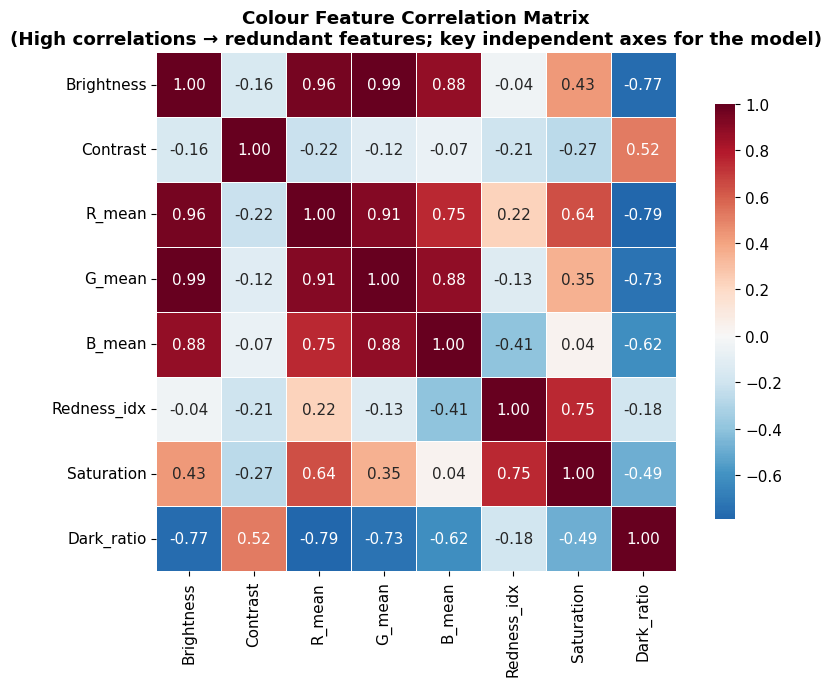

In [27]:
colour_features = qual_df[['Brightness','Contrast','R_mean','G_mean','B_mean',
                            'Redness_idx','Saturation','Dark_ratio']]
corr = colour_features.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, square=True, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Colour Feature Correlation Matrix\n'
             '(High correlations → redundant features; key independent axes for the model)')
plt.tight_layout()
plt.show()

---
# 6 · Texture & Contrast Analysis
*Texture (fine detail structure) is a primary diagnostic cue in dermatology - scale patterns, papules, vesicles, and erosions all manifest as texture differences.*

In [28]:
# Texture proxy: high-frequency energy via Laplacian variance
# A blurry/smooth image has low Laplacian variance; a textured image has high variance
from PIL import ImageFilter

texture_rows = []
for cls in classes:
    folder   = os.path.join(train_path, cls)
    all_imgs = [f for f in os.listdir(folder)
                if f.lower().endswith(('.png','.jpg','.jpeg','.bmp','.tiff'))]
    sample   = random.sample(all_imgs, min(20, len(all_imgs)))
    for fname in sample:
        fpath = os.path.join(folder, fname)
        try:
            with Image.open(fpath) as img:
                gray = img.convert('L').resize((128,128))
                lap  = gray.filter(ImageFilter.FIND_EDGES)
                lap_arr = np.array(lap, dtype=float)
                texture_rows.append({
                    'Class':           cls,
                    'Texture_energy':  lap_arr.var(),          # Laplacian variance
                    'Edge_mean':       lap_arr.mean(),          # mean edge strength
                })
        except Exception:
            continue

tex_df = pd.DataFrame(texture_rows)
print(f'Texture stats: {len(tex_df)} images.')

Texture stats: 460 images.


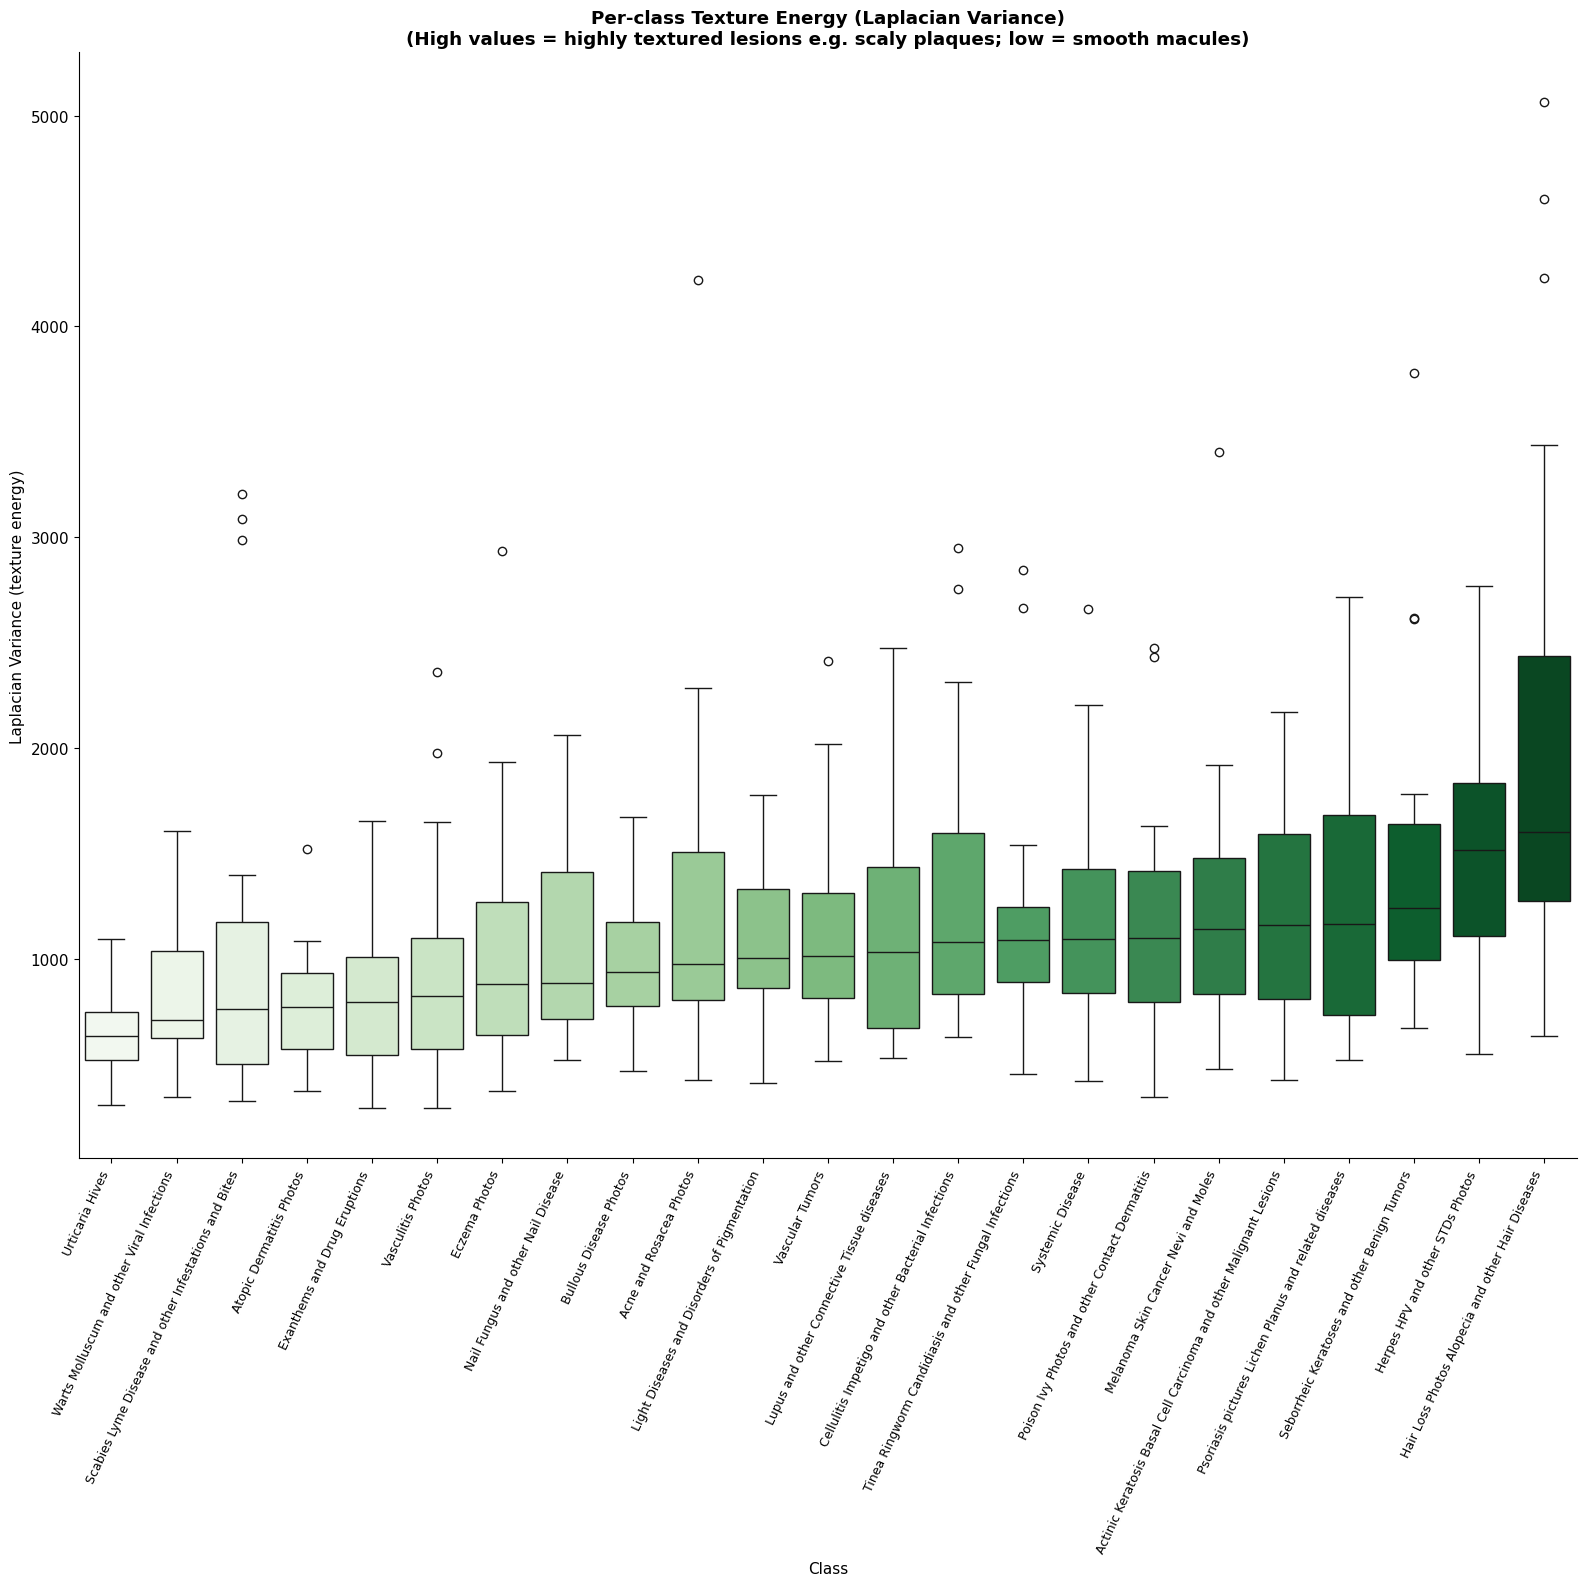

In [29]:
order_t = tex_df.groupby('Class')['Texture_energy'].median().sort_values().index
fig, ax = plt.subplots(figsize=(16, 16))
sns.boxplot(data=tex_df, x='Class', y='Texture_energy', order=order_t,
            palette='Greens', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=65, ha='right', fontsize=9)
ax.set_ylabel('Laplacian Variance (texture energy)')
ax.set_title('Per-class Texture Energy (Laplacian Variance)\n'
             '(High values = highly textured lesions e.g. scaly plaques; low = smooth macules)')
plt.tight_layout()
plt.show()

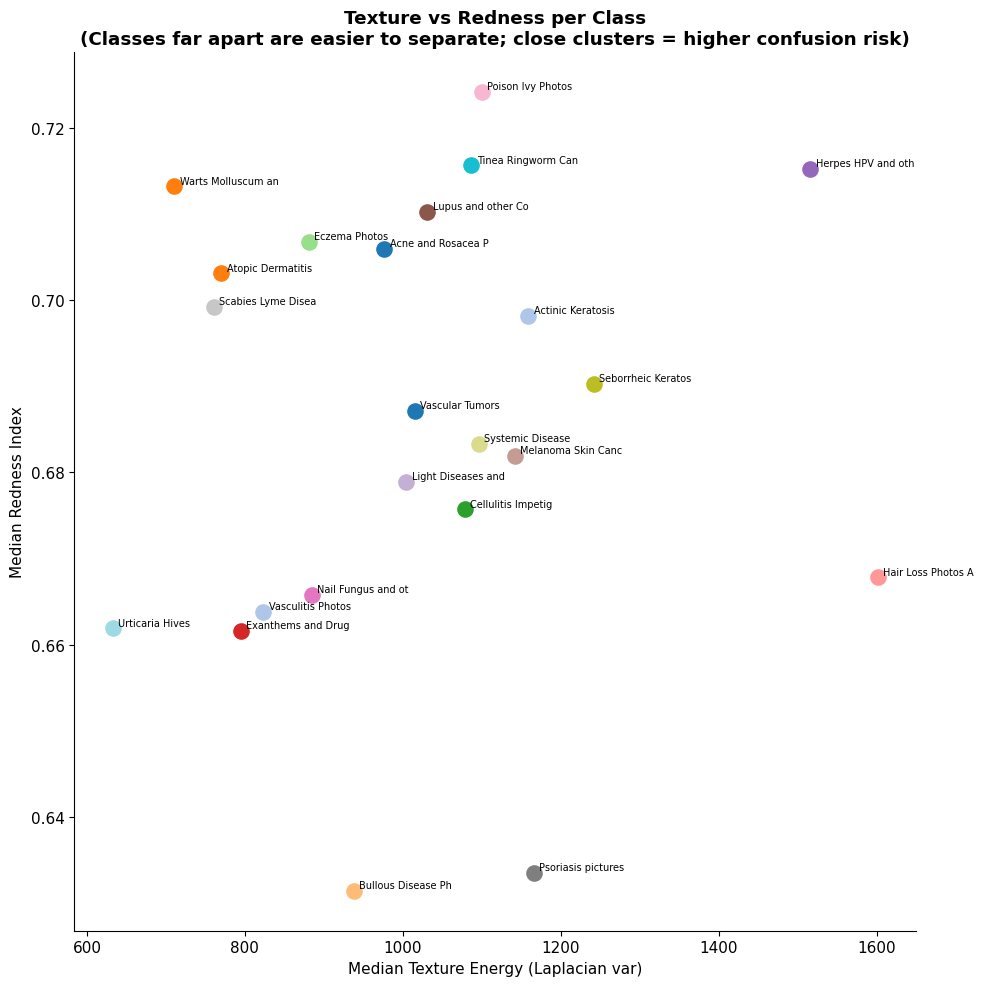

In [30]:
# Merge texture and colour summaries for a combined view
tex_summary  = tex_df.groupby('Class')['Texture_energy'].median().reset_index()
qual_summary = qual_df.groupby('Class')['Redness_idx'].median().reset_index()
combined     = tex_summary.merge(qual_summary, on='Class')

fig, ax = plt.subplots(figsize=(10, 10))
scatter_colors = sns.color_palette('tab20', len(combined))
for i, row in combined.iterrows():
    ax.scatter(row['Texture_energy'], row['Redness_idx'],
               color=scatter_colors[i], s=120, zorder=3)
    ax.annotate(row['Class'][:18], (row['Texture_energy'], row['Redness_idx']),
                fontsize=7, xytext=(4, 2), textcoords='offset points')
ax.set_xlabel('Median Texture Energy (Laplacian var)')
ax.set_ylabel('Median Redness Index')
ax.set_title('Texture vs Redness per Class\n'
             '(Classes far apart are easier to separate; close clusters = higher confusion risk)')
plt.tight_layout()
plt.show()

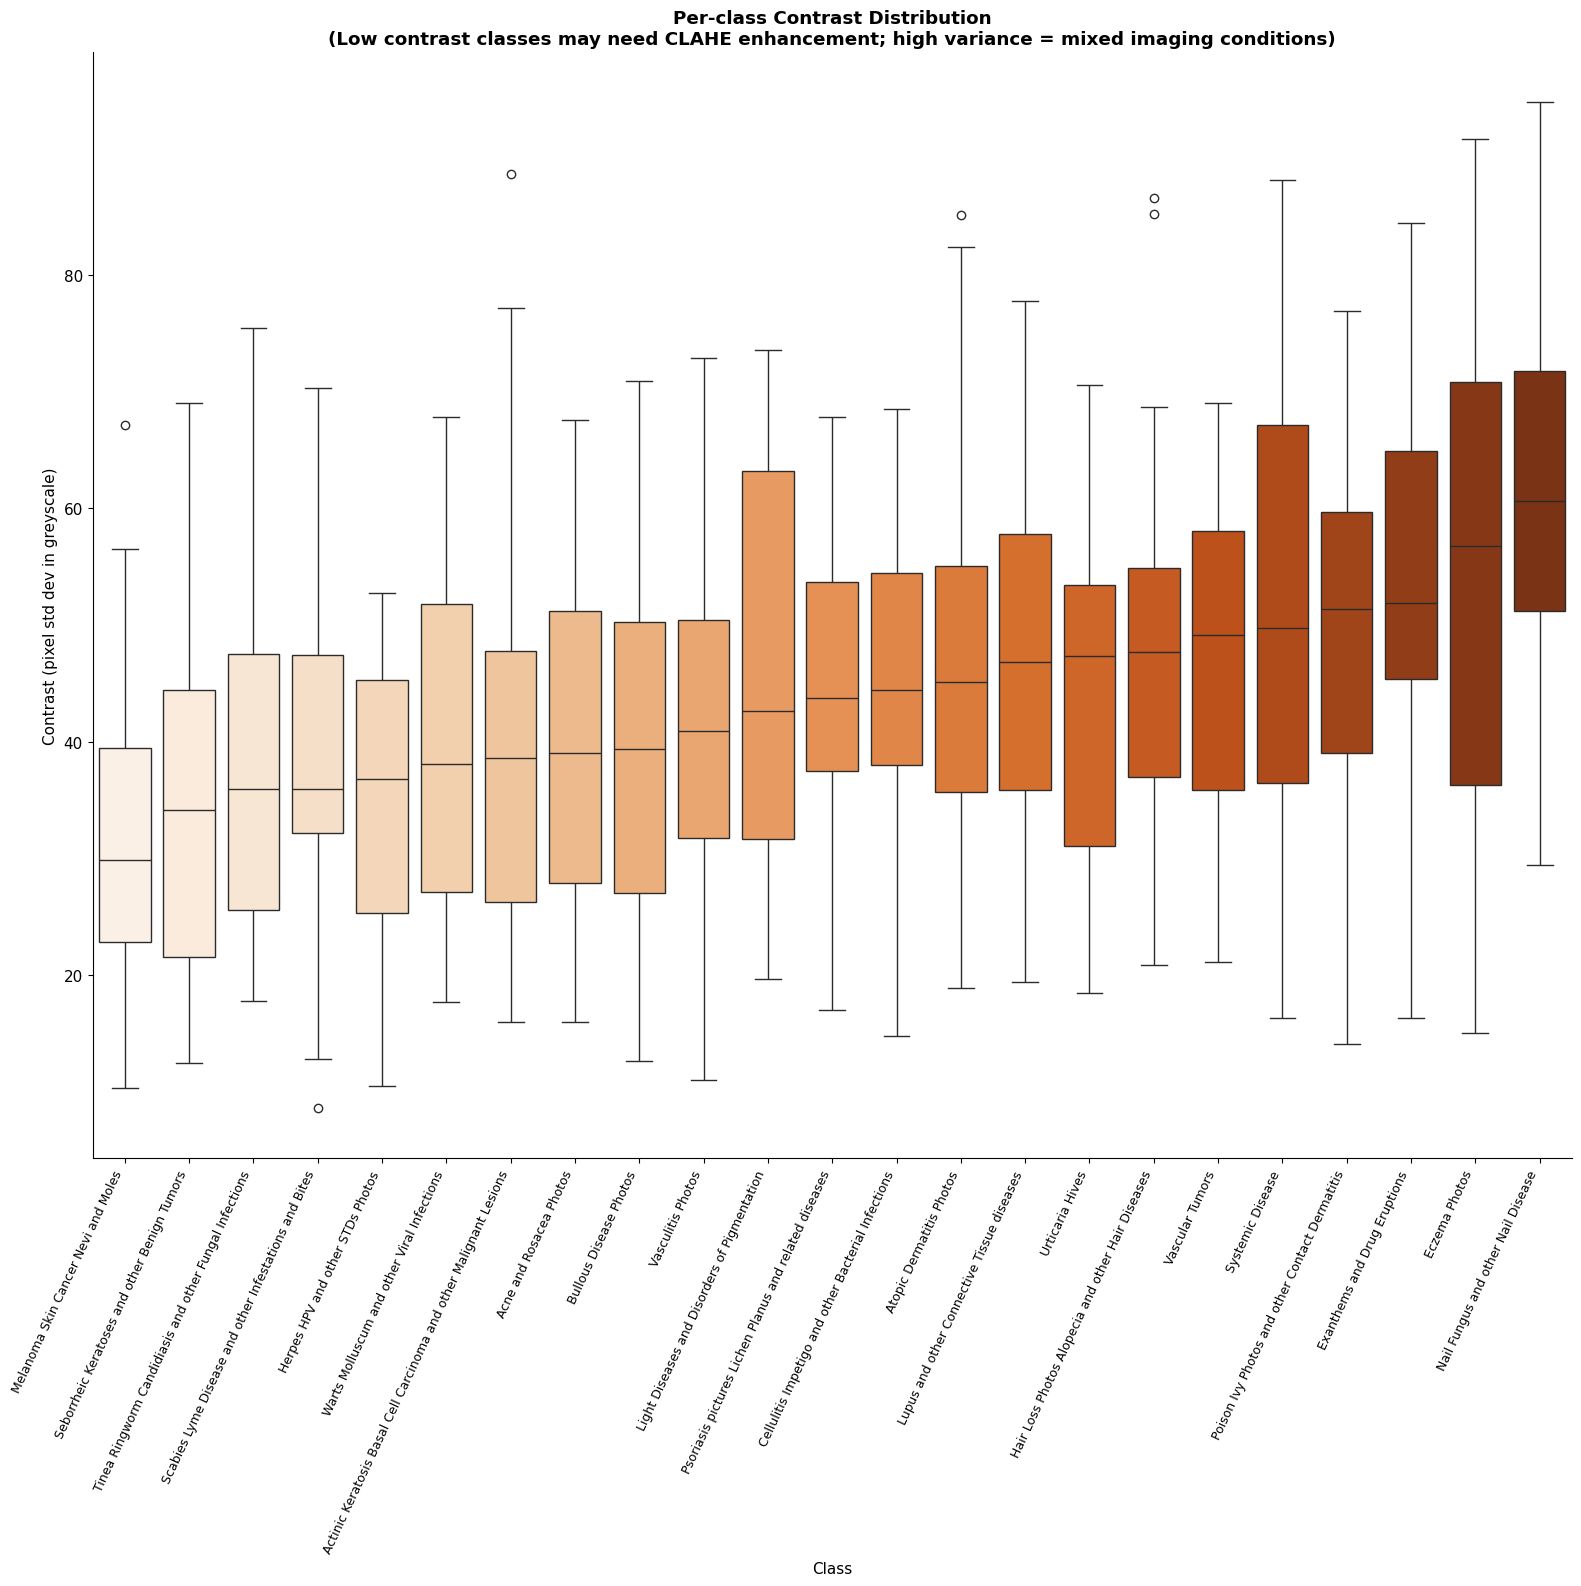

In [31]:
order_c = qual_df.groupby('Class')['Contrast'].median().sort_values().index
fig, ax = plt.subplots(figsize=(16, 16))
sns.boxplot(data=qual_df, x='Class', y='Contrast', order=order_c,
            palette='Oranges', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=65, ha='right', fontsize=9)
ax.set_ylabel('Contrast (pixel std dev in greyscale)')
ax.set_title('Per-class Contrast Distribution\n'
             '(Low contrast classes may need CLAHE enhancement; high variance = mixed imaging conditions)')
plt.tight_layout()
plt.show()

---
# 7 · Duplicate Detection & Removal
*Duplicates within train inflate metrics. Duplicates across train/test constitute data leakage - which in a medical AI context could produce falsely optimistic performance on unseen patients.*

In [32]:
def hash_directory(root):
    hmap = defaultdict(list)
    for dirpath, _, files in os.walk(root):
        for f in files:
            if f.lower().endswith(('.png','.jpg','.jpeg','.bmp','.tiff')):
                fp = os.path.join(dirpath, f)
                try:
                    hmap[hashlib.md5(open(fp,'rb').read()).hexdigest()].append(fp)
                except Exception: pass
    return hmap

print('Hashing train set...')
train_hmap = hash_directory(train_path)
print('Hashing test set...')
test_hmap  = hash_directory(test_path)

train_dupes = {h:ps for h,ps in train_hmap.items() if len(ps)>1}
test_dupes  = {h:ps for h,ps in test_hmap.items()  if len(ps)>1}
leakage     = set(train_hmap.keys()) & set(test_hmap.keys())

print(f'\nTrain duplicate groups : {len(train_dupes):,}')
print(f'Test  duplicate groups : {len(test_dupes):,}')
print(f'Cross-set leakage      : {len(leakage):,} images')

if leakage:
    print('\nLeakage by class:')
    lc = Counter(os.path.basename(os.path.dirname(train_hmap[h][0])) for h in leakage)
    for cls, cnt in lc.most_common(): print(f'  {cls}: {cnt}')

Hashing train set...
Hashing test set...

Train duplicate groups : 1
Test  duplicate groups : 0
Cross-set leakage      : 0 images


## 7.1 Data Integrity Issues: Internal Duplicates & Train/Test Leakage

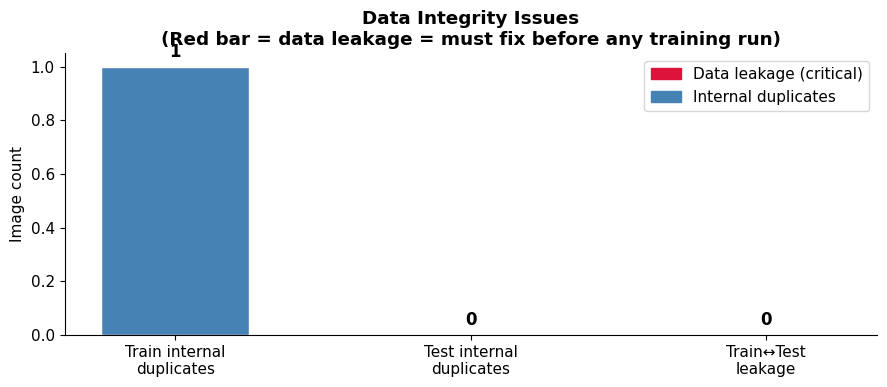

In [33]:
issues = {
    'Train internal\nduplicates': sum(len(p)-1 for p in train_dupes.values()),
    'Test internal\nduplicates':  sum(len(p)-1 for p in test_dupes.values()),
    'Train↔Test\nleakage':       len(leakage),
}
fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ['steelblue', 'steelblue', 'crimson']
bars = ax.bar(issues.keys(), issues.values(), color=bar_colors, edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%d', padding=4, fontsize=12, fontweight='bold')
ax.set_ylabel('Image count')
ax.set_title('Data Integrity Issues\n'
             '(Red bar = data leakage = must fix before any training run)')
red_p  = mpatches.Patch(color='crimson',   label='Data leakage (critical)')
blue_p = mpatches.Patch(color='steelblue', label='Internal duplicates')
ax.legend(handles=[red_p, blue_p])
plt.tight_layout()
plt.show()

## Automated Duplicate Removal & Post-Cleanup Verification

In [34]:
removed_train = removed_leak = 0

for h, paths in train_dupes.items():
    for p in sorted(paths)[1:]:
        try: os.remove(p); removed_train += 1
        except Exception as e: print(f'  Could not remove {p}: {e}')

for h in leakage:
    for tp in test_hmap[h]:
        try: os.remove(tp); removed_leak += 1
        except Exception as e: print(f'  Could not remove {tp}: {e}')

train_clean = count_images(train_path, classes)
test_clean  = count_images(test_path,  classes)
print(f'Within-train duplicates removed : {removed_train}')
print(f'Leaked test images removed      : {removed_leak}')
print(f'Post-cleanup train : {train_clean["Count"].sum():,}  |  test : {test_clean["Count"].sum():,}')

Within-train duplicates removed : 1
Leaked test images removed      : 0
Post-cleanup train : 14,893  |  test : 3,409


## 7.2 Before vs After Deduplication: Dataset Size & Class Distribution

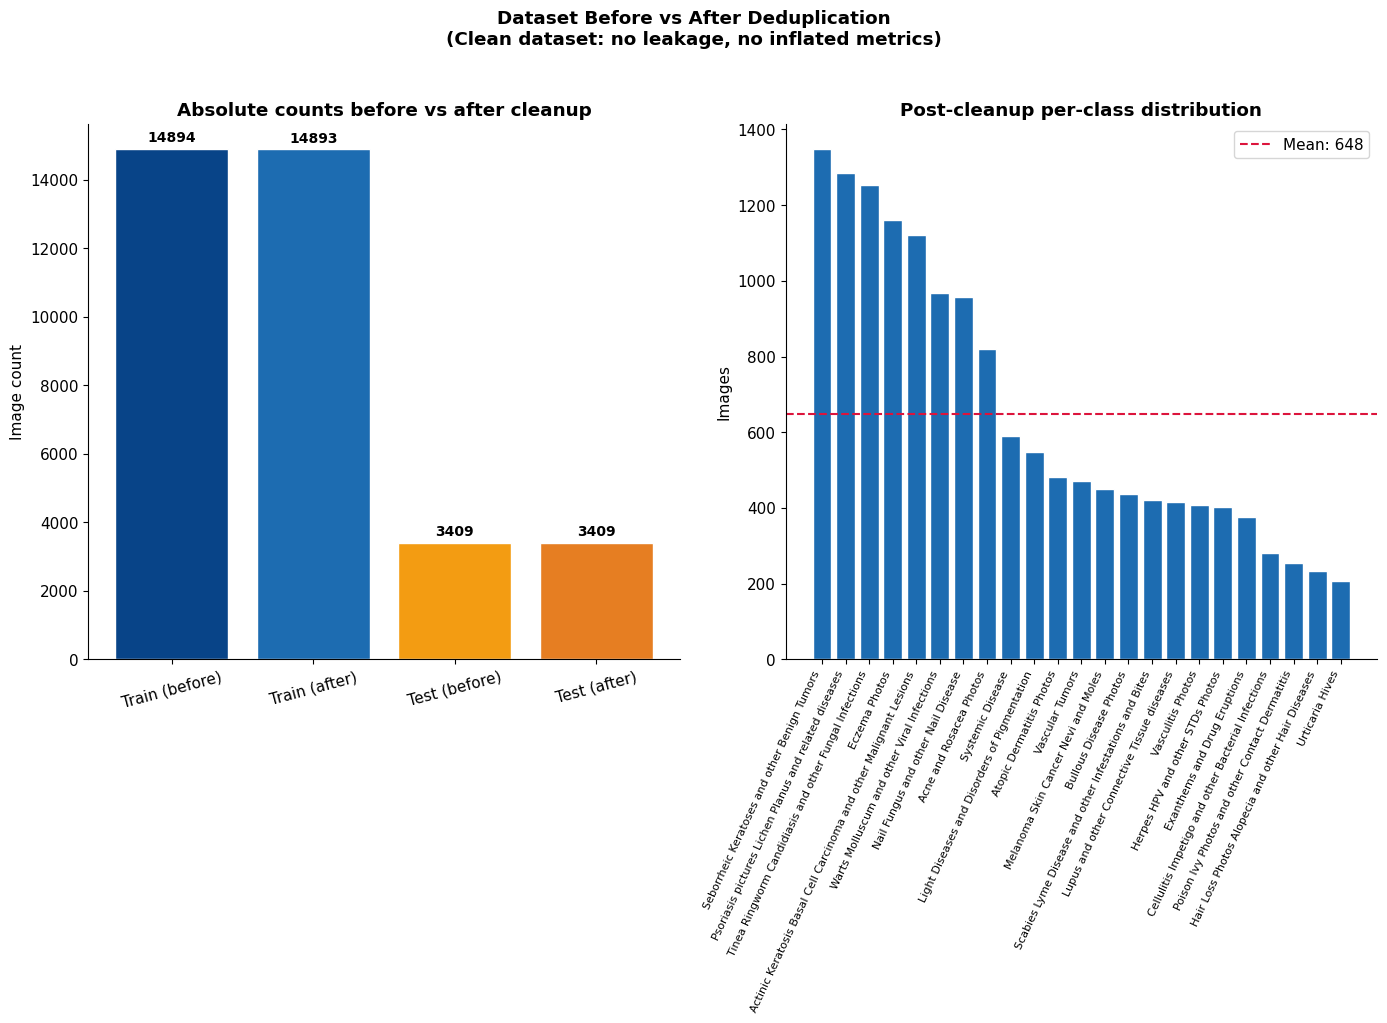

In [35]:
before_train = dist_df['Train'].sum()
before_test  = dist_df['Test'].sum()
after_train  = train_clean['Count'].sum()
after_test   = test_clean['Count'].sum()

labels = ['Train (before)', 'Train (after)', 'Test (before)', 'Test (after)']
values = [before_train, after_train, before_test, after_test]
bar_c  = [BLUE_PAL[0], BLUE_PAL[2], '#f39c12', '#e67e22']

fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# Left: absolute counts
bars = axes[0].bar(labels, values, color=bar_c, edgecolor='white')
axes[0].bar_label(bars, fmt='%d', padding=3, fontsize=10, fontweight='bold')
axes[0].set_ylabel('Image count')
axes[0].set_title('Absolute counts before vs after cleanup')
axes[0].tick_params(axis='x', rotation=15)

# Right: per-class post-cleanup distribution
axes[1].bar(train_clean.sort_values('Count',ascending=False)['Class'],
            train_clean.sort_values('Count',ascending=False)['Count'],
            color=BLUE_PAL[2], edgecolor='white')
axes[1].set_xticklabels(
    train_clean.sort_values('Count',ascending=False)['Class'],
    rotation=65, ha='right', fontsize=8)
axes[1].axhline(train_clean['Count'].mean(), color='crimson', linestyle='--',
                label=f"Mean: {train_clean['Count'].mean():.0f}")
axes[1].set_ylabel('Images'); axes[1].legend()
axes[1].set_title('Post-cleanup per-class distribution')

fig.suptitle('Dataset Before vs After Deduplication\n'
             '(Clean dataset: no leakage, no inflated metrics)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 9 · Modelling Implications
*Every EDA finding mapped to a concrete model or pipeline decision.*

In [36]:
largest_post  = train_clean['Count'].max()
smallest_post = train_clean['Count'].min()
ratio_post    = largest_post / smallest_post

implications = [
    ('Class imbalance',
     f'Ratio {ratio_post:.1f}:1  |  Gini {gini:.3f}',
     'Use class-weighted CrossEntropyLoss or Focal Loss.\n'
     'Consider RandomOverSampler / augmentation-based oversampling for minority classes.\n'
     'Report per-class F1, precision, recall — NOT just accuracy.'),

    ('Image size variability',
     f'W [{min(widths)},{max(widths)}]  H [{min(heights)},{max(heights)}]',
     'Standardise to fixed resolution (224×224 for EfficientNet/ResNet).\n'
     'Centre-crop + resize preferred over stretch — preserves lesion morphology.'),

    ('Aspect ratio spread',
     f'Range [{min(aspects):.2f},{max(aspects):.2f}]  mean {np.mean(aspects):.2f}',
     'Pad to square before resize to avoid distorting lesion shapes.\n'
     'Ablate padding vs centre-crop — test both in validation.'),

    ('Non-RGB images',
     f'{grayscale_pct:.1f}% non-RGB',
     'Enforce img.convert("RGB") in DataLoader. Non-RGB crashes pretrained backbones.'),

    ('Colour is discriminative',
     'Redness index varies significantly across classes',
     'Do NOT convert to greyscale. Use ImageNet mean/std normalisation.\n'
     'Apply colour jitter augmentation — but with conservative parameters\n'
     '(aggressive jitter removes clinically meaningful colour signal).'),

    ('Acquisition variability',
     'Wide per-class brightness spread',
     'Apply random brightness/contrast augmentation during training.\n'
     'Consider CLAHE preprocessing to reduce camera artefacts.'),

    ('Texture differences',
     'Laplacian variance separates classes',
     'Fine-grained texture is signal — use sufficient input resolution (≥224px).\n'
     'Avoid aggressive blur augmentation.'),

    ('Data leakage (post-cleanup)',
     f'{removed_leak} images removed',
     'Re-run duplicate check after any future dataset update.\n'
     'Verify with a final hash comparison before each training run.'),

    ('Small test coverage per class',
     'Some classes <10% test coverage',
     'Use stratified 5-fold CV rather than a single fixed split.\n'
     'Ensures every class has evaluation examples in every fold.'),
]

print('EDA → MODELLING IMPLICATIONS')
print('='*65)
for title, finding, rec in implications:
    print(f'\n  [{title}]')
    print(f'    Finding : {finding}')
    print(f'    Action  : {rec}')

print('\n' + '='*65)
print('  EDA COMPLETE')
print('='*65)

EDA → MODELLING IMPLICATIONS

  [Class imbalance]
    Finding : Ratio 6.5:1  |  Gini 0.308
    Action  : Use class-weighted CrossEntropyLoss or Focal Loss.
Consider RandomOverSampler / augmentation-based oversampling for minority classes.
Report per-class F1, precision, recall — NOT just accuracy.

  [Image size variability]
    Finding : W [314,720]  H [359,1128]
    Action  : Standardise to fixed resolution (224×224 for EfficientNet/ResNet).
Centre-crop + resize preferred over stretch — preserves lesion morphology.

  [Aspect ratio spread]
    Finding : Range [0.44,1.84]  mean 1.28
    Action  : Pad to square before resize to avoid distorting lesion shapes.
Ablate padding vs centre-crop — test both in validation.

  [Non-RGB images]
    Finding : 0.0% non-RGB
    Action  : Enforce img.convert("RGB") in DataLoader. Non-RGB crashes pretrained backbones.

  [Colour is discriminative]
    Finding : Redness index varies significantly across classes
    Action  : Do NOT convert to greyscal